# Question 1 — physical activity in London

This notebook describes physical activity at four connected levels: London overall, Inner and Outer London, boroughs, and individual respondents. Each section begins with observed percentages that can be read directly, then adds statistical explanation only after the main pattern is visible. This order keeps the analysis accessible while still separating long-term differences, seasonal movement and exceptional periods where the data allow it.

## Data used

The prepared files contain eight survey waves at London, Inner/Outer, borough and respondent levels. Activity status is divided into three mutually exclusive groups: Active, Fairly Active and Inactive. Specific activity indicators can overlap because one person may report several activities. Survey weights are used for respondent summaries, while `effective_n` is retained for uncertainty and aggregate modelling.

In [1]:
# Establish the analysis environment and load the prepared panels.
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from patsy import build_design_matrices
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
DATA_DIR = PROJECT_ROOT / 'question1_outputs' / 'prepared_data'
EXTRA_DIR = PROJECT_ROOT / 'extradata'
PATHS = {
    'Annual': DATA_DIR / 'q1_annual.csv',
    'Quarterly': DATA_DIR / 'q1_quarterly.csv',
    'Monthly': DATA_DIR / 'q1_monthly.csv',
    'Age': DATA_DIR / 'q1_age_annual.csv',
    'Respondent': DATA_DIR / 'q1_respondents_8wave.csv',
    'Boundary': EXTRA_DIR / 'london_borough_boundaries.geojson',
}
assert all(path.exists() for path in PATHS.values()), PATHS

frequency_frames = {name: pd.read_csv(PATHS[name]) for name in ['Annual', 'Quarterly', 'Monthly']}
frequency_frames['Monthly']['period_start'] = pd.to_datetime(frequency_frames['Monthly']['period_start'])
for column in ['quarter_start', 'quarter_end']:
    frequency_frames['Quarterly'][column] = pd.to_datetime(frequency_frames['Quarterly'][column])

level_codes = {'London': 'London', 'Inner/Outer': 'InnerOuter', 'Borough': 'Borough'}
panels = {
    (level, frequency): frame.loc[frame['geography_level'].eq(code)].copy()
    for frequency, frame in frequency_frames.items()
    for level, code in level_codes.items()
}
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {'inactive_rate': 'Inactive', 'fairly_active_rate': 'Fairly active', 'active_rate': 'Active'}
COLORS = {'inactive_rate': '#C44E52', 'fairly_active_rate': '#DD8452', 'active_rate': '#55A868'}

# Curated broad activities; overlapping parent/subtype pairs are deliberately excluded.
ACTIVITIES = {
    'WALKTRAV_B02': 'Walking for travel', 'CYCTRAV_B04': 'Cycling for travel',
    'DANCEART_B05': 'Creative/artistic dance', 'GARD_B08': 'Gardening',
    'WINTER_C10': 'Winter sports', 'BOWLSBOULES_C12': 'Bowls or boules',
    'GYMTRAMPCHEER_C13': 'Gymnastics/trampolining/cheerleading',
    'FOOTBALL_F01': 'Football', 'RUGBYUNION_F03': 'Rugby union',
    'NETBALL_F06': 'Netball', 'BASKETBALL_F07': 'Basketball', 'HOCKEY_F09': 'Hockey',
    'VOLLEYBALL_F10': 'Volleyball', 'TENNIS_G01': 'Tennis', 'BADMINTON_G02': 'Badminton',
    'TABLETENNIS_G03': 'Table tennis', 'ORIENTEERING_H04': 'Orienteering',
    'PARKOUR_H05': 'Parkour/free running', 'ICESKATING_I02': 'Ice skating',
    'TENPIN_I04': 'Ten-pin bowling', 'SNOOKER_I06': 'Snooker', 'POOL_I07': 'Pool',
    'DARTS_I08': 'Darts', 'ARCHERY_J01': 'Archery', 'MARTIAL_J07': 'Martial arts',
    'TRACKANDFIELD_L02': 'Track and field', 'FELLRUNNING_L04': 'Fell running',
    'TRIATHLON_L05': 'Triathlon', 'GOLF_L08': 'Golf', 'EQUEST_L09': 'Equestrian',
    'BOCCIA_L11': 'Boccia', 'ROLLERSKATING_L16': 'Rollerskating',
    'SKATEBOARDING_L17': 'Skateboarding', 'MOTORSPORTS_L18': 'Motor sports',
    'CYCLEISURE_N01': 'Cycling for leisure', 'DANCEOTHER_O01': 'Other dancing',
    'ROCKCLIMB_R01': 'Rock climbing/bouldering', 'ROWINGWATER_R04': 'Rowing on water',
    'BOXINGTRAD_S01': 'Boxing', 'RUNJOG_U07': 'Running/jogging',
}
ACTIVITY_COLUMNS = {suffix: f'MONTHS12_RATE_{suffix}' for suffix in ACTIVITIES}
assert set(ACTIVITY_COLUMNS.values()).issubset(frequency_frames['Annual'].columns)

# Clear activity families used for respondent-level structure; these are not exhaustive sport categories.
ACTIVITY_FAMILIES = {
    'Travel': ['WALKTRAV_B02', 'CYCTRAV_B04'],
    'Team sports': ['FOOTBALL_F01', 'RUGBYUNION_F03', 'NETBALL_F06', 'BASKETBALL_F07', 'HOCKEY_F09', 'VOLLEYBALL_F10'],
    'Racquet sports': ['TENNIS_G01', 'BADMINTON_G02', 'TABLETENNIS_G03'],
    'Dance / gym': ['DANCEART_B05', 'GYMTRAMPCHEER_C13', 'DANCEOTHER_O01'],
    'Outdoor / endurance': ['ORIENTEERING_H04', 'PARKOUR_H05', 'TRACKANDFIELD_L02', 'FELLRUNNING_L04',
                            'TRIATHLON_L05', 'ROWINGWATER_R04', 'RUNJOG_U07'],
    'Wheeled activities': ['ROLLERSKATING_L16', 'SKATEBOARDING_L17'],
}
assert all(set(values).issubset(ACTIVITIES) for values in ACTIVITY_FAMILIES.values())

The following setup defines the common rules used throughout the notebook. Approximate intervals use the effective sample size, respondent summaries use the survey weight, and the same four COVID periods are applied whenever monthly comparisons are made. Keeping these definitions fixed prevents later sections from answering similar questions with slightly different samples or conventions.

In [2]:
# Reusable estimators keep uncertainty, weighting and COVID phase definitions consistent.
def add_rate_intervals(frame, targets=TARGETS):
    """Add approximate 95% intervals using each row's effective sample size."""
    result = frame.copy()
    for target in targets:
        se = np.sqrt(result[target] * (1 - result[target]) / result['effective_n'])
        result[f'{target}_low'] = (result[target] - 1.96 * se).clip(0, 1)
        result[f'{target}_high'] = (result[target] + 1.96 * se).clip(0, 1)
    return result


def weighted_mean(values, weights):
    """Return a weighted mean after excluding invalid values and weights."""
    values, weights = np.asarray(values, float), np.asarray(weights, float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return float(np.average(values[valid], weights=weights[valid]))


def weighted_group_rate(frame, groups, outcome='active_binary', weight='wt_final'):
    """Summarise a binary outcome and its effective sample size by groups."""
    rows = []
    grouper = groups[0] if len(groups) == 1 else groups
    for keys, group in frame.groupby(grouper, observed=True, sort=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        weights = group[weight].to_numpy(float)
        rows.append({
            **dict(zip(groups, keys)),
            'active_rate': weighted_mean(group[outcome], weights),
            'effective_n': weights.sum() ** 2 / np.square(weights).sum(),
            'respondent_n': len(group),
        })
    return pd.DataFrame(rows)


def add_covid_phase(frame):
    """Apply the same pre-COVID, restriction, reopening and later-period definition."""
    result = frame.copy()
    result['covid_phase'] = np.select(
        [
            result['period_start'].le(pd.Timestamp('2020-02-01')),
            result['period_start'].le(pd.Timestamp('2021-06-01')),
            result['period_start'].le(pd.Timestamp('2022-02-01')),
        ],
        ['Pre-COVID', 'High restriction', 'Reopening/recovery'],
        default='Low restriction/post',
    )
    order = ['Pre-COVID', 'High restriction', 'Reopening/recovery', 'Low restriction/post']
    result['covid_phase'] = pd.Categorical(result['covid_phase'], categories=order, ordered=True)
    return result

# 1. London overall

The London-wide view begins with the three activity-status shares. The coloured table makes the Year 1 to Year 8 movement immediately visible, while the adjacent annual series shows every intervening estimate and its uncertainty. Looking at both is important: the endpoints summarise the net change, but the full path reveals whether it was gradual, temporary or irregular.

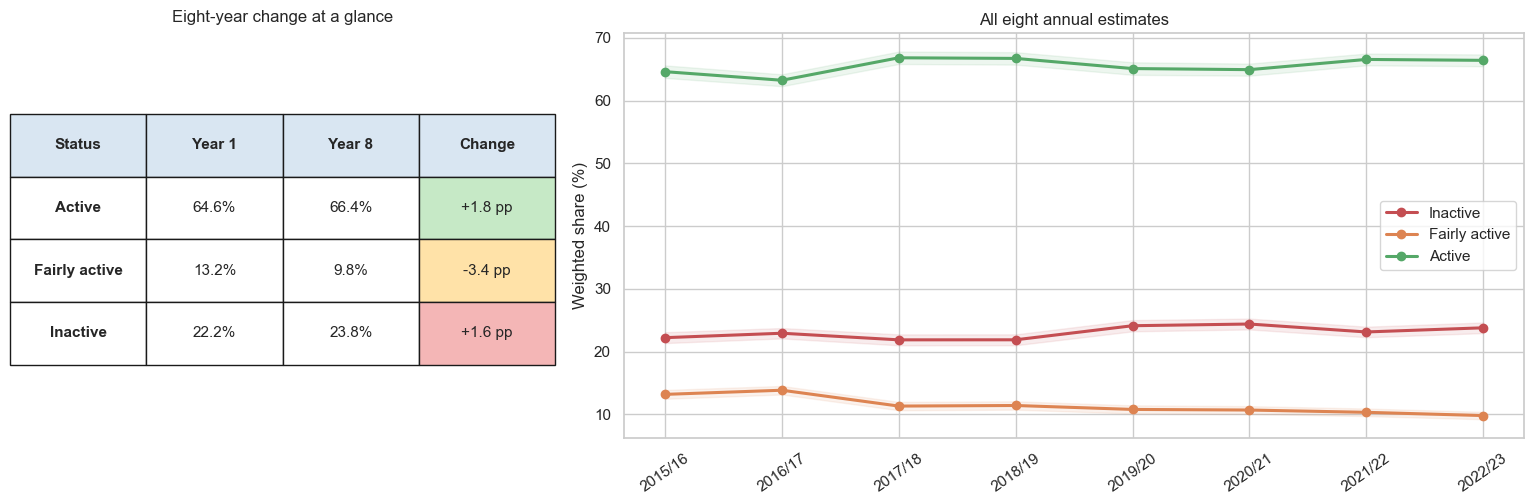

,Status,Year 1,Year 8,Change
0,Active,64.62,66.43,1.81
1,Fairly active,13.17,9.79,-3.38
2,Inactive,22.21,23.78,1.57


In [3]:
# Summarise the endpoint change, then show all eight annual estimates.
london_annual = add_rate_intervals(panels[('London', 'Annual')]).sort_values('year')
london_monthly = add_covid_phase(panels[('London', 'Monthly')].sort_values('period_start'))

summary_rows = []
for target in ['active_rate', 'fairly_active_rate', 'inactive_rate']:
    year1 = london_annual.loc[london_annual['year'].eq(1), target].iloc[0] * 100
    year8 = london_annual.loc[london_annual['year'].eq(8), target].iloc[0] * 100
    summary_rows.append([TARGET_LABELS[target], year1, year8, year8 - year1])
status_summary = pd.DataFrame(summary_rows, columns=['Status', 'Year 1', 'Year 8', 'Change'])

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2), gridspec_kw={'width_ratios': [1, 1.65]})
axes[0].axis('off')
table_text = [[row['Status'], f"{row['Year 1']:.1f}%", f"{row['Year 8']:.1f}%", f"{row['Change']:+.1f} pp"]
              for _, row in status_summary.iterrows()]
table = axes[0].table(cellText=table_text, colLabels=['Status', 'Year 1', 'Year 8', 'Change'],
                      loc='center', cellLoc='center', colLoc='center', bbox=[0, .18, 1, .62])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)
for column in range(4):
    table[(0, column)].set_facecolor('#D9E6F2')
    table[(0, column)].set_text_props(weight='bold')
change_colors = {'Active': '#C6E9C6', 'Fairly active': '#FFE2A8', 'Inactive': '#F4B6B6'}
for row_index, status in enumerate(status_summary['Status'], start=1):
    table[(row_index, 3)].set_facecolor(change_colors[status])
    table[(row_index, 0)].set_text_props(weight='bold')
axes[0].set_title('Eight-year change at a glance', pad=8)

x = np.arange(len(london_annual))
for target in TARGETS:
    axes[1].plot(x, london_annual[target] * 100, marker='o', linewidth=2.2,
                 color=COLORS[target], label=TARGET_LABELS[target])
    axes[1].fill_between(x, london_annual[f'{target}_low'] * 100,
                         london_annual[f'{target}_high'] * 100,
                         color=COLORS[target], alpha=.10)
axes[1].set_xticks(x, london_annual['survey_wave'], rotation=35)
axes[1].set(title='All eight annual estimates', xlabel='', ylabel='Weighted share (%)')
axes[1].legend(title='')
fig.tight_layout()
plt.show()
display(status_summary.round(2))

Annual averages can hide substantial movement inside each survey wave. The next figure therefore returns to the observed monthly Active percentages: the time series preserves the original chronology, and the heatmap displays the actual percentage in every wave-month cell. A three-month rolling line is included only as a visual guide; it does not replace the monthly observations.

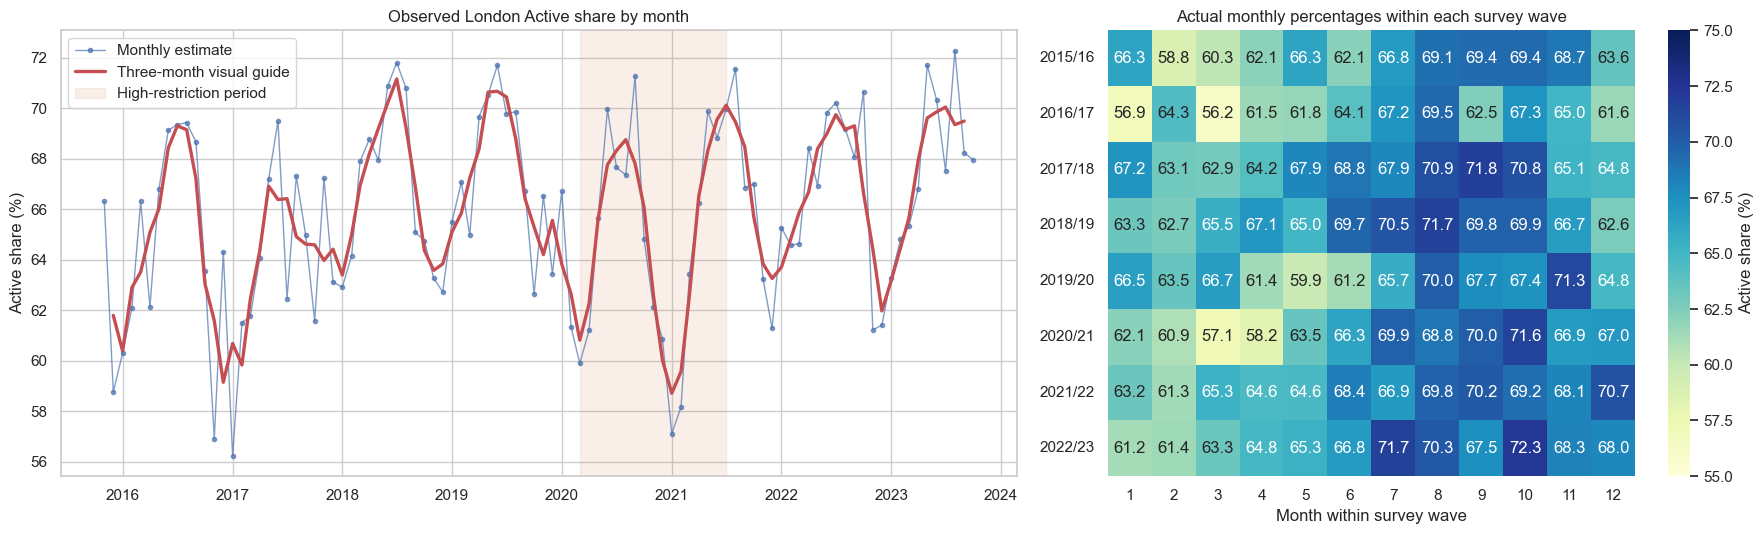

In [4]:
# Display the original monthly Active estimates before applying any decomposition.
london_monthly['active_pct'] = london_monthly['active_rate'] * 100
london_monthly['time_trend'] = london_monthly['month_index'] - 1
london_monthly['rolling_3m_pct'] = london_monthly['active_pct'].rolling(3, center=True).mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), gridspec_kw={'width_ratios': [1.45, 1]})
axes[0].plot(london_monthly['period_start'], london_monthly['active_pct'], marker='o', markersize=3,
             linewidth=1, color='#4C72B0', alpha=.70, label='Monthly estimate')
axes[0].plot(london_monthly['period_start'], london_monthly['rolling_3m_pct'], linewidth=2.4,
             color='#C44E52', label='Three-month visual guide')
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'), color='#DD8452', alpha=.13,
                label='High-restriction period')
axes[0].set(title='Observed London Active share by month', xlabel='', ylabel='Active share (%)')
axes[0].legend(title='')

season_matrix = london_monthly.pivot(index='survey_wave', columns='month_of_wave', values='active_pct')
sns.heatmap(season_matrix, cmap='YlGnBu', annot=True, fmt='.1f', vmin=55, vmax=75,
            cbar_kws={'label': 'Active share (%)'}, ax=axes[1])
axes[1].set(title='Actual monthly percentages within each survey wave',
            xlabel='Month within survey wave', ylabel='')
fig.tight_layout()
plt.show()

The raw series suggests repeated seasonal movement, a slower underlying path and several unusually weak months. Seasonal-trend decomposition now separates these three components. The variance bar is a descriptive sequential allocation of monthly variation, not a causal attribution: “remainder” includes exceptional shocks, survey noise and any structure not captured by the smooth trend or 12-month seasonal cycle.

COVID-period estimates are shown afterwards. They control for trend, month within wave and online response rate, but they still describe period differences rather than proving that restrictions caused the entire change.

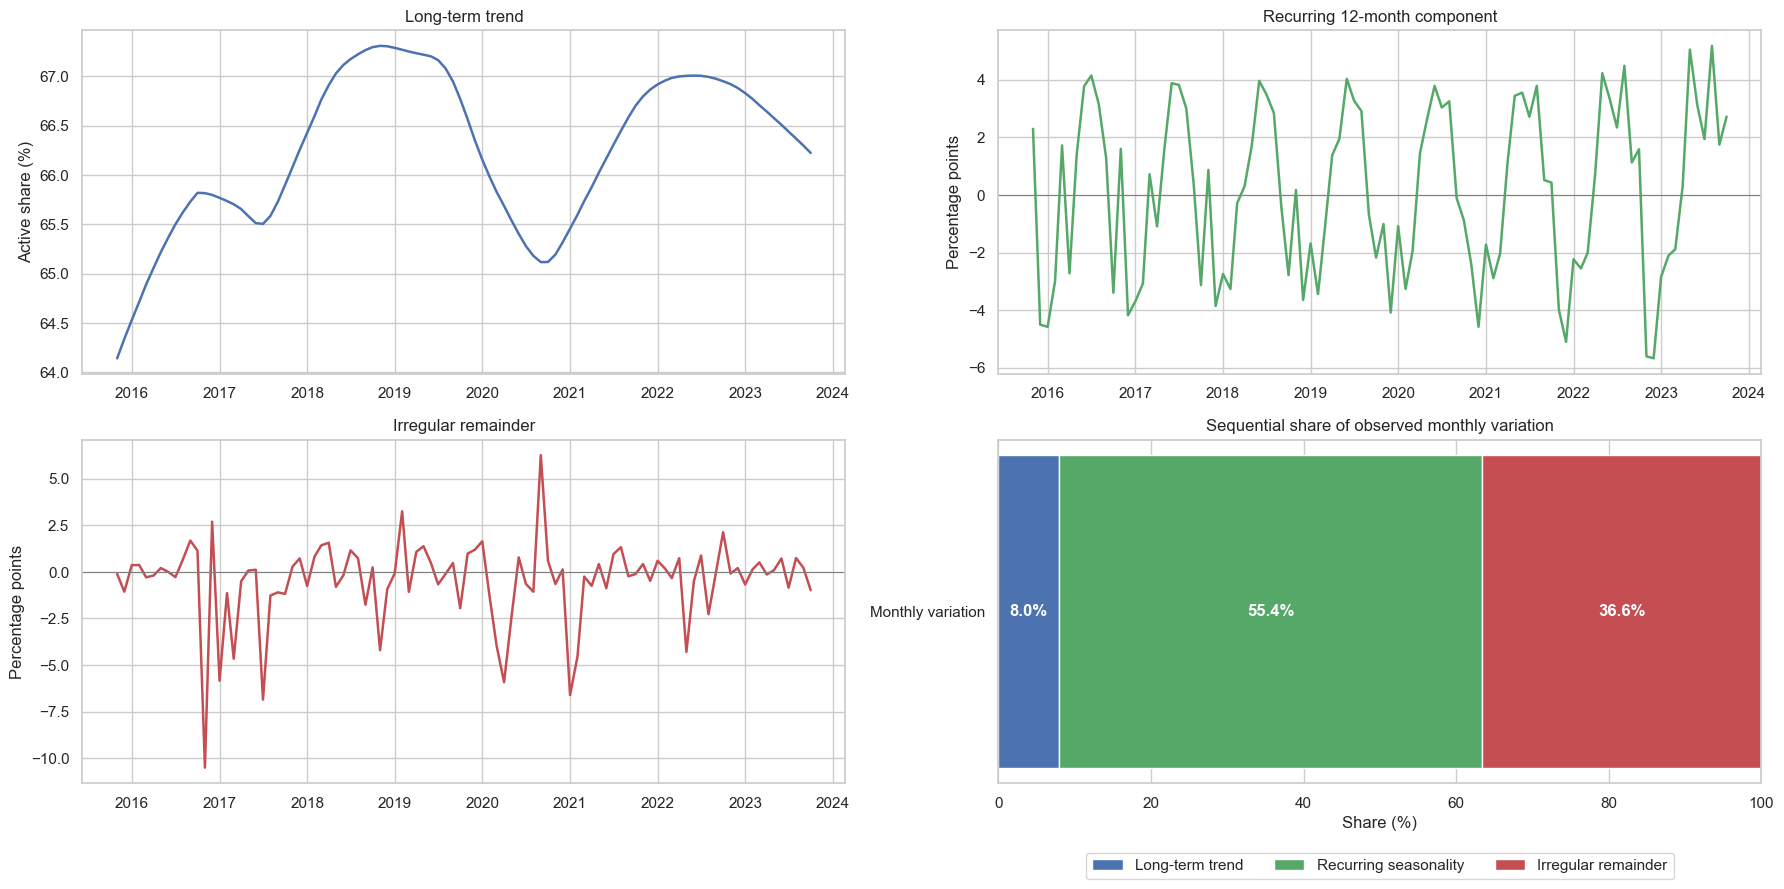

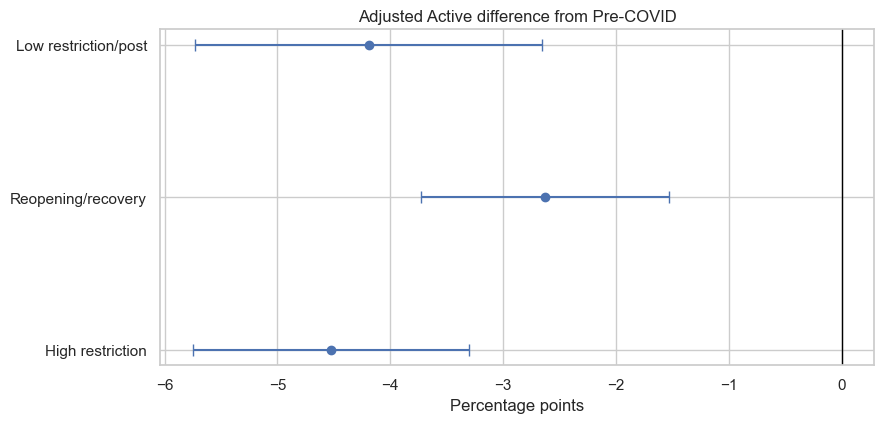

,component,share_pct
0,Long-term trend,8.0
1,Recurring seasonality,55.4
2,Irregular remainder,36.6


,phase,difference_pp,low,high,p_value
0,High restriction,-4.53,-5.75,-3.30,0.0
1,Reopening/recovery,-2.63,-3.73,-1.53,0.0
2,Low restriction/post,-4.19,-5.73,-2.65,0.0


In [5]:
# Separate the monthly series into trend, recurring seasonality and an irregular remainder.
def sequential_variation_shares(observed, trend, seasonal):
    """Allocate variation sequentially to trend, seasonality and the remaining component."""
    observed = np.asarray(observed, float)
    trend = np.asarray(trend, float)
    seasonal = np.asarray(seasonal, float)
    total = np.square(observed - observed.mean()).sum()
    after_trend = np.square(observed - trend).sum()
    remainder = np.square(observed - trend - seasonal).sum()
    components = np.array([
        max(total - after_trend, 0),
        max(after_trend - remainder, 0),
        max(remainder, 0),
    ])
    return 100 * components / components.sum()


stl_result = STL(london_monthly['active_pct'], period=12, robust=True).fit()
london_monthly['stl_trend'] = stl_result.trend
london_monthly['stl_seasonal'] = stl_result.seasonal
london_monthly['stl_remainder'] = stl_result.resid
variation_shares = pd.DataFrame({
    'component': ['Long-term trend', 'Recurring seasonality', 'Irregular remainder'],
    'share_pct': sequential_variation_shares(
        london_monthly['active_pct'], london_monthly['stl_trend'], london_monthly['stl_seasonal'])
})

phase_order = list(london_monthly['covid_phase'].cat.categories)
phase_model = smf.wls(
    'active_pct ~ time_trend + C(month_of_wave) + '
    'C(covid_phase, Treatment(reference="Pre-COVID")) + online_response_rate',
    data=london_monthly, weights=london_monthly['effective_n'],
).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
phase_rows = []
for phase in phase_order[1:]:
    term = f'C(covid_phase, Treatment(reference="Pre-COVID"))[T.{phase}]'
    interval = phase_model.conf_int().loc[term]
    phase_rows.append({'phase': phase, 'difference_pp': phase_model.params[term],
                       'low': interval.iloc[0], 'high': interval.iloc[1],
                       'p_value': phase_model.pvalues[term]})
phase_effects = pd.DataFrame(phase_rows)

fig, axes = plt.subplots(2, 2, figsize=(18, 9))
for column, title, color, axis in [
    ('stl_trend', 'Long-term trend', '#4C72B0', axes[0, 0]),
    ('stl_seasonal', 'Recurring 12-month component', '#55A868', axes[0, 1]),
    ('stl_remainder', 'Irregular remainder', '#C44E52', axes[1, 0]),
]:
    axis.plot(london_monthly['period_start'], london_monthly[column], color=color, linewidth=1.8)
    axis.axhline(0, color='grey', linewidth=.8) if column != 'stl_trend' else None
    axis.set(title=title, xlabel='', ylabel='Percentage points' if column != 'stl_trend' else 'Active share (%)')

left = 0
component_colors = ['#4C72B0', '#55A868', '#C44E52']
for (_, row), color in zip(variation_shares.iterrows(), component_colors):
    axes[1, 1].barh(['Monthly variation'], row['share_pct'], left=left, color=color, label=row['component'])
    axes[1, 1].text(left + row['share_pct'] / 2, 0, f"{row['share_pct']:.1f}%", ha='center', va='center',
                    color='white', weight='bold')
    left += row['share_pct']
axes[1, 1].set(title='Sequential share of observed monthly variation', xlabel='Share (%)', ylabel='')
axes[1, 1].set_xlim(0, 100)
axes[1, 1].legend(title='', loc='upper center', bbox_to_anchor=(.5, -.18), ncol=3)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.errorbar(phase_effects['difference_pp'], phase_effects['phase'],
            xerr=[phase_effects['difference_pp'] - phase_effects['low'],
                  phase_effects['high'] - phase_effects['difference_pp']],
            fmt='o', color='#4C72B0', capsize=4)
ax.axvline(0, color='black', linewidth=1)
ax.set(title='Adjusted Active difference from Pre-COVID', xlabel='Percentage points', ylabel='')
fig.tight_layout()
plt.show()
display(variation_shares.round(1))
display(phase_effects.round({'difference_pp': 2, 'low': 2, 'high': 2, 'p_value': 3}))

# 2. Inner and Outer London

The second level asks whether the London-wide result is shared across Inner and Outer London. The annual series establishes the observed gap first. Monthly models then compare each area's COVID-period movement with its own Pre-COVID level before testing the more demanding question of whether the gap between the two areas changed.

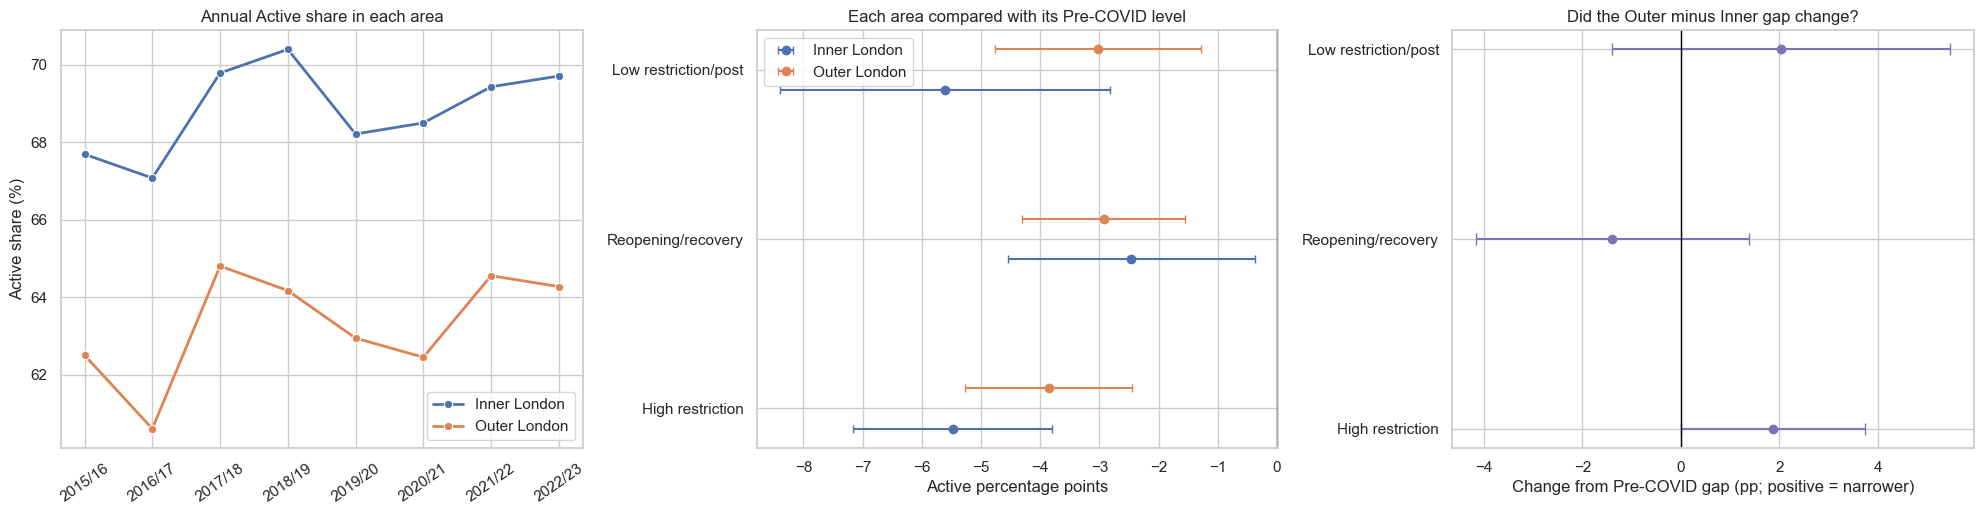

,phase,gap_change_pp,low,high,p_value
0,High restriction,1.87,-0.00,3.74,0.050
1,Reopening/recovery,-1.39,-4.16,1.38,0.324
2,Low restriction/post,2.03,-1.41,5.47,0.247


In [6]:
# Show the observed area series, then estimate separate COVID-period effects and the gap change.
area_annual = add_rate_intervals(panels[('Inner/Outer', 'Annual')]).sort_values(['year', 'geography_name'])
area_monthly = add_covid_phase(panels[('Inner/Outer', 'Monthly')].sort_values('period_start'))
area_annual['active_pct'] = area_annual['active_rate'] * 100
area_monthly['active_pct'] = area_monthly['active_rate'] * 100
area_monthly['time_trend'] = area_monthly['month_index'] - 1

area_phase_rows = []
for area_name, group in area_monthly.groupby('geography_name'):
    local_model = smf.wls(
        'active_pct ~ time_trend + C(month_of_wave) + '
        'C(covid_phase, Treatment(reference="Pre-COVID")) + online_response_rate',
        data=group, weights=group['effective_n'],
    ).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
    for phase in phase_order[1:]:
        term = f'C(covid_phase, Treatment(reference="Pre-COVID"))[T.{phase}]'
        interval = local_model.conf_int().loc[term]
        area_phase_rows.append({'area': area_name, 'phase': phase, 'difference_pp': local_model.params[term],
                                'low': interval.iloc[0], 'high': interval.iloc[1]})
area_phase_effects = pd.DataFrame(area_phase_rows)

gap_rates = area_monthly.pivot(index='period_start', columns='geography_name', values='active_rate')
gap_online = area_monthly.pivot(index='period_start', columns='geography_name', values='online_response_rate')
gap_neff = area_monthly.pivot(index='period_start', columns='geography_name', values='effective_n')
gap_frame = area_monthly[['period_start', 'year', 'month_of_wave', 'month_index', 'covid_phase']].drop_duplicates('period_start').set_index('period_start')
gap_frame['gap_pp'] = (gap_rates['Outer London'] - gap_rates['Inner London']) * 100
gap_frame['online_gap_pp'] = (gap_online['Outer London'] - gap_online['Inner London']) * 100
gap_frame['gap_weight'] = 2 / (1 / gap_neff['Outer London'] + 1 / gap_neff['Inner London'])
gap_frame['time_trend'] = gap_frame['month_index'] - 1
gap_frame = gap_frame.reset_index()
gap_phase_model = smf.wls(
    'gap_pp ~ time_trend + C(month_of_wave) + '
    'C(covid_phase, Treatment(reference="Pre-COVID")) + online_gap_pp',
    data=gap_frame, weights=gap_frame['gap_weight'],
).fit(cov_type='HAC', cov_kwds={'maxlags': 12})
gap_phase_rows = []
for phase in phase_order[1:]:
    term = f'C(covid_phase, Treatment(reference="Pre-COVID"))[T.{phase}]'
    interval = gap_phase_model.conf_int().loc[term]
    gap_phase_rows.append({'phase': phase, 'gap_change_pp': gap_phase_model.params[term],
                           'low': interval.iloc[0], 'high': interval.iloc[1], 'p_value': gap_phase_model.pvalues[term]})
gap_phase_effects = pd.DataFrame(gap_phase_rows)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.3))
sns.lineplot(data=area_annual, x='survey_wave', y='active_pct', hue='geography_name', marker='o', linewidth=2, ax=axes[0])
axes[0].set(title='Annual Active share in each area', xlabel='', ylabel='Active share (%)')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='')

area_colors = {'Inner London': '#4C72B0', 'Outer London': '#DD8452'}
phase_positions = np.arange(3)
for area_name, offset in [('Inner London', -.12), ('Outer London', .12)]:
    local = area_phase_effects.loc[area_phase_effects['area'].eq(area_name)].set_index('phase').reindex(phase_order[1:])
    axes[1].errorbar(local['difference_pp'], phase_positions + offset,
                     xerr=[local['difference_pp'] - local['low'], local['high'] - local['difference_pp']],
                     fmt='o', capsize=3, color=area_colors[area_name], label=area_name)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_yticks(phase_positions, phase_order[1:])
axes[1].set(title='Each area compared with its Pre-COVID level', xlabel='Active percentage points', ylabel='')
axes[1].legend(title='')

axes[2].errorbar(gap_phase_effects['gap_change_pp'], gap_phase_effects['phase'],
                 xerr=[gap_phase_effects['gap_change_pp'] - gap_phase_effects['low'],
                       gap_phase_effects['high'] - gap_phase_effects['gap_change_pp']],
                 fmt='o', color='#8172B2', capsize=4)
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set(title='Did the Outer minus Inner gap change?',
            xlabel='Change from Pre-COVID gap (pp; positive = narrower)', ylabel='')
fig.tight_layout()
plt.show()
display(gap_phase_effects.round({'gap_change_pp': 2, 'low': 2, 'high': 2, 'p_value': 3}))

The observed Inner London advantage may reflect who lives in each area as well as different participation among people of the same age. Age standardisation separates these two parts for every year and for the eight-year average. This is an age decomposition rather than a complete causal explanation: the remaining component can still include other population differences, local conditions and survey noise.

Specific activities are then compared using raw participation rates. The weighted eight-year average is the main description of persistent structure, and the adjacent heatmap shows the Inner–Outer gap in every survey year. This makes persistent differences easy to distinguish from one-year reversals or isolated endpoint changes.

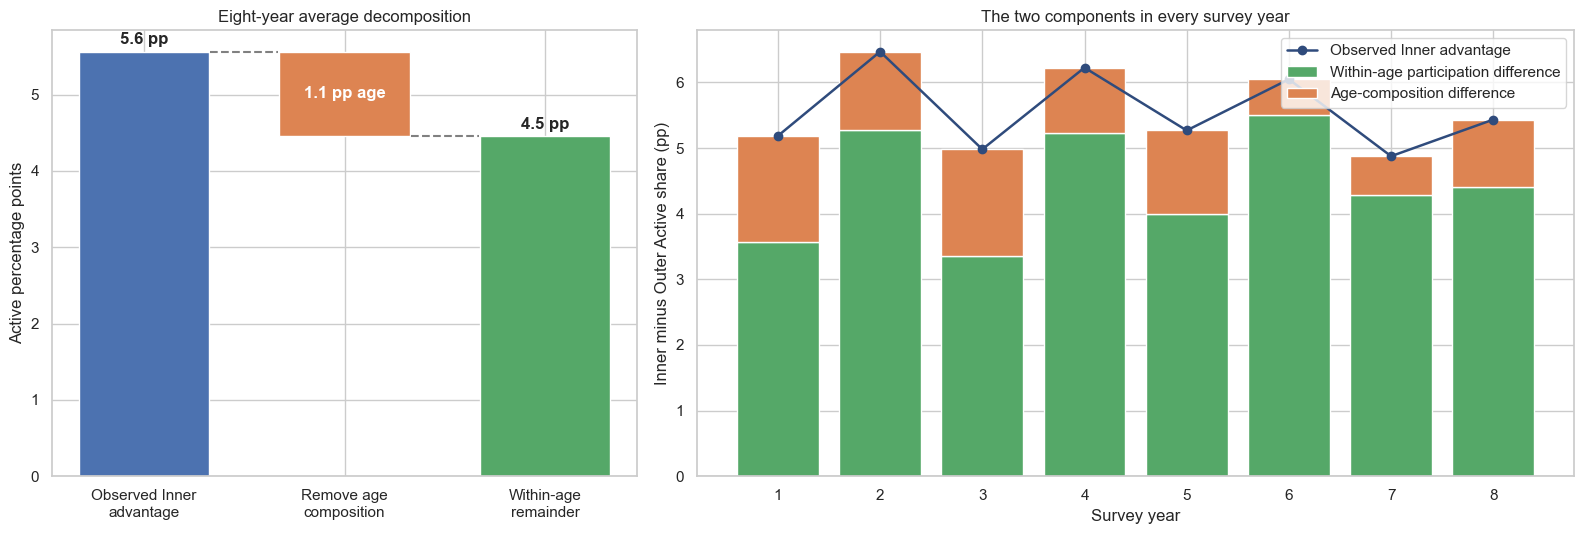

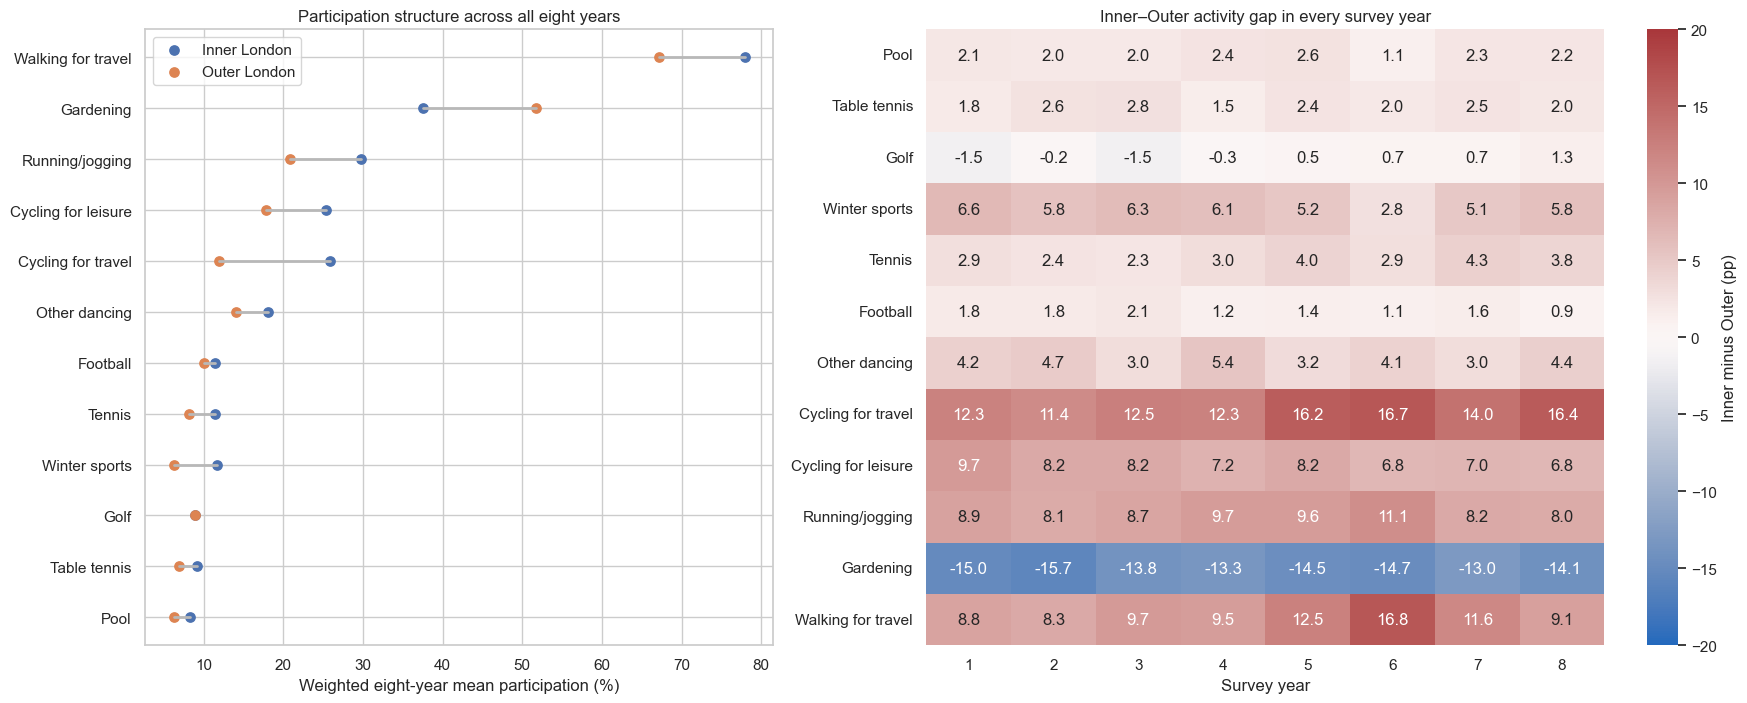

,year,raw_inner_advantage_pp,age_standardised_inner_advantage_pp,age_composition_component_pp
0,1,5.19,3.58,1.61
1,2,6.47,5.28,1.19
2,3,4.98,3.35,1.63
3,4,6.23,5.23,1.00
4,5,5.27,4.00,1.27
5,6,6.05,5.51,0.54
6,7,4.88,4.28,0.59
7,8,5.43,4.40,1.03


In [7]:
# Decompose the age effect, then compare long-run and endpoint activity gaps.
age_annual = pd.read_csv(PATHS['Age'])
age_london = age_annual.loc[age_annual['geography_level'].eq('London'), ['year', 'age_band', 'population_share']]
age_area = age_annual.loc[age_annual['geography_level'].eq('InnerOuter')].merge(
    age_london.rename(columns={'population_share': 'london_age_share'}), on=['year', 'age_band'], validate='many_to_one')
standardised_area = age_area.assign(weighted_active=lambda x: x['london_age_share'] * x['active_rate']).groupby(
    ['year', 'geography_name'], as_index=False)['weighted_active'].sum()
standardised_gap = standardised_area.pivot(index='year', columns='geography_name', values='weighted_active')
raw_gap_year = area_annual.pivot(index='year', columns='geography_name', values='active_rate')
gap_decomposition = pd.DataFrame({
    'raw_inner_advantage_pp': (raw_gap_year['Inner London'] - raw_gap_year['Outer London']) * 100,
    'age_standardised_inner_advantage_pp': (standardised_gap['Inner London'] - standardised_gap['Outer London']) * 100,
}).reset_index()
gap_decomposition['age_composition_component_pp'] = (
    gap_decomposition['raw_inner_advantage_pp'] - gap_decomposition['age_standardised_inner_advantage_pp'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'width_ratios': [1, 1.5]})
raw_advantage = gap_decomposition['raw_inner_advantage_pp'].mean()
age_component = gap_decomposition['age_composition_component_pp'].mean()
within_age_component = gap_decomposition['age_standardised_inner_advantage_pp'].mean()
axes[0].bar(0, raw_advantage, color='#4C72B0', width=.65)
axes[0].bar(1, age_component, bottom=within_age_component, color='#DD8452', width=.65)
axes[0].bar(2, within_age_component, color='#55A868', width=.65)
axes[0].plot([.33, .67], [raw_advantage, raw_advantage], color='grey', linestyle='--')
axes[0].plot([1.33, 1.67], [within_age_component, within_age_component], color='grey', linestyle='--')
axes[0].set_xticks([0, 1, 2], ['Observed Inner\nadvantage', 'Remove age\ncomposition', 'Within-age\nremainder'])
axes[0].set(title='Eight-year average decomposition', ylabel='Active percentage points')
axes[0].text(0, raw_advantage + .10, f'{raw_advantage:.1f} pp', ha='center', weight='bold')
axes[0].text(1, within_age_component + age_component / 2, f'{age_component:.1f} pp age', ha='center', va='center', color='white', weight='bold')
axes[0].text(2, within_age_component + .10, f'{within_age_component:.1f} pp', ha='center', weight='bold')

axes[1].bar(gap_decomposition['year'], gap_decomposition['age_standardised_inner_advantage_pp'],
            color='#55A868', label='Within-age participation difference')
axes[1].bar(gap_decomposition['year'], gap_decomposition['age_composition_component_pp'],
            bottom=gap_decomposition['age_standardised_inner_advantage_pp'], color='#DD8452',
            label='Age-composition difference')
axes[1].plot(gap_decomposition['year'], gap_decomposition['raw_inner_advantage_pp'],
             color='#2F4B7C', marker='o', linewidth=1.8, label='Observed Inner advantage')
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].set(title='The two components in every survey year', xlabel='Survey year',
            ylabel='Inner minus Outer Active share (pp)')
axes[1].legend(title='')
fig.tight_layout()
plt.show()

# Build yearly raw activity rates and an effective-sample-size weighted eight-year summary.
area_activity_yearly_rows = []
for suffix, label in ACTIVITIES.items():
    column = ACTIVITY_COLUMNS[suffix]
    for _, row in area_annual.iterrows():
        area_activity_yearly_rows.append({
            'year': row['year'], 'activity': label, 'area': row['geography_name'],
            'participation_pct': row[column] * 100, 'effective_n': row['effective_n'],
        })
area_activity_yearly = pd.DataFrame(area_activity_yearly_rows)

area_activity_rows = []
for (activity, area_name), group in area_activity_yearly.groupby(['activity', 'area']):
    area_activity_rows.append({
        'activity': activity, 'area': area_name,
        'mean_pct': weighted_mean(group['participation_pct'], group['effective_n']),
    })
area_activity = pd.DataFrame(area_activity_rows)
mean_wide = area_activity.pivot(index='activity', columns='area', values='mean_pct')
mean_wide['London mean'] = mean_wide[['Inner London', 'Outer London']].mean(axis=1)
leading_activities = mean_wide.nlargest(12, 'London mean').sort_values('London mean').index

gap_by_year = area_activity_yearly.pivot(
    index=['activity', 'year'], columns='area', values='participation_pct'
).reset_index()
gap_by_year['inner_minus_outer_pp'] = gap_by_year['Inner London'] - gap_by_year['Outer London']
gap_matrix = gap_by_year.loc[gap_by_year['activity'].isin(leading_activities)].pivot(
    index='activity', columns='year', values='inner_minus_outer_pp'
).reindex(leading_activities)

fig, axes = plt.subplots(1, 2, figsize=(18, 7.2), gridspec_kw={'width_ratios': [1, 1.35]})
for y, activity in enumerate(leading_activities):
    inner, outer = mean_wide.loc[activity, ['Inner London', 'Outer London']]
    axes[0].plot([inner, outer], [y, y], color='#B8B8B8', linewidth=2)
    axes[0].scatter(inner, y, color='#4C72B0', s=45, label='Inner London' if y == 0 else None)
    axes[0].scatter(outer, y, color='#DD8452', s=45, label='Outer London' if y == 0 else None)
axes[0].set_yticks(range(len(leading_activities)), leading_activities)
axes[0].set(title='Participation structure across all eight years',
            xlabel='Weighted eight-year mean participation (%)', ylabel='')
axes[0].legend(title='')

gap_limit = np.ceil(np.nanmax(np.abs(gap_matrix.to_numpy())) / 5) * 5
sns.heatmap(gap_matrix, cmap='vlag', center=0, vmin=-gap_limit, vmax=gap_limit,
            annot=True, fmt='.1f', cbar_kws={'label': 'Inner minus Outer (pp)'}, ax=axes[1])
axes[1].set(title='Inner–Outer activity gap in every survey year',
            xlabel='Survey year', ylabel='')
fig.tight_layout()
plt.show()
display(gap_decomposition.round(2))

Raw percentages remain the main evidence, but a specialisation index adds one useful perspective: it asks whether an activity is proportionally more common in Inner or Outer London after accounting for its overall prevalence. The index is the log base 2 of the Inner-to-Outer participation-rate ratio. A value of +1 means twice the Outer rate; −1 means half. Activities below 1% London-wide participation are excluded so very rare items do not dominate the ranking.

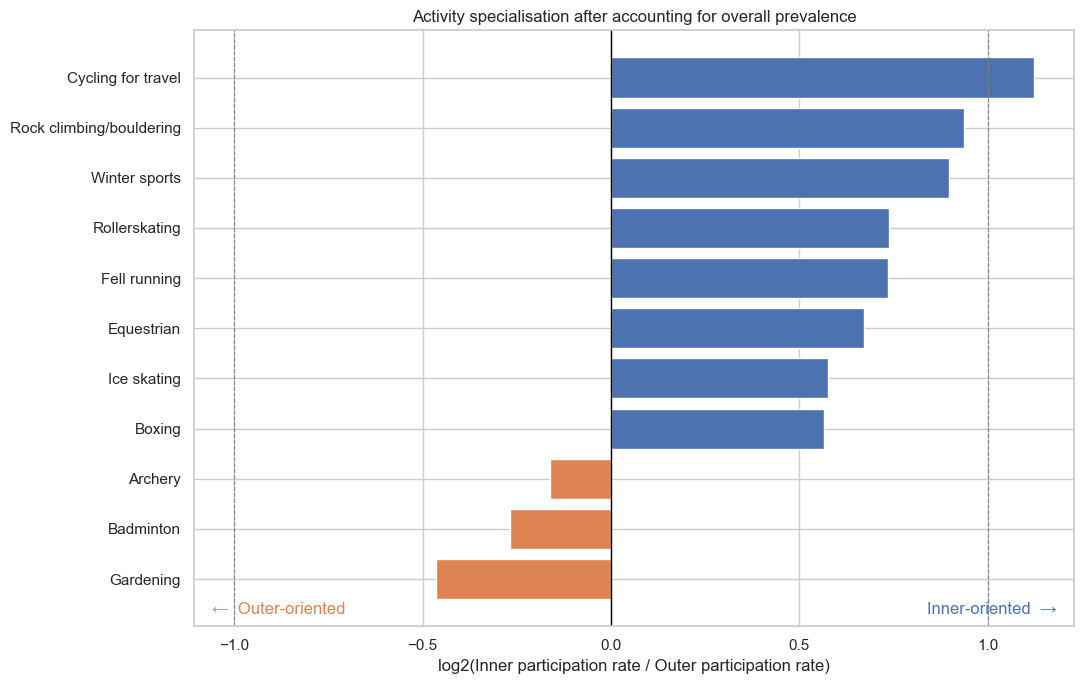

area,Inner London,Outer London,London mean,log2_inner_outer_ratio
activity,,,,
Gardening,37.48,51.73,44.60,-0.46
Badminton,5.84,7.04,6.44,-0.27
Archery,1.01,1.13,1.07,-0.16
Boxing,3.14,2.11,2.62,0.57
Ice skating,5.09,3.40,4.25,0.58
Equestrian,1.92,1.18,1.55,0.67
Fell running,1.66,0.98,1.32,0.74
Rollerskating,1.48,0.87,1.18,0.74
Winter sports,11.64,6.22,8.93,0.90


In [8]:
# Identify activities that are proportionally Inner- or Outer-oriented.
def activity_specialisation(activity_table, minimum_mean=1.0):
    """Calculate a stable Inner-to-Outer log rate ratio above a prevalence threshold."""
    wide = activity_table.pivot(index='activity', columns='area', values='mean_pct').copy()
    wide['London mean'] = wide[['Inner London', 'Outer London']].mean(axis=1)
    wide = wide.loc[wide['London mean'].ge(minimum_mean)].copy()
    wide['log2_inner_outer_ratio'] = np.log2(
        (wide['Inner London'] + .05) / (wide['Outer London'] + .05))
    return wide.sort_values('log2_inner_outer_ratio')


specialisation = activity_specialisation(area_activity)
meaningful_specialisation = specialisation.loc[
    specialisation['log2_inner_outer_ratio'].abs().ge(.10)
]
specialisation_plot = pd.concat([
    meaningful_specialisation.loc[meaningful_specialisation['log2_inner_outer_ratio'].lt(0)].head(6),
    meaningful_specialisation.loc[meaningful_specialisation['log2_inner_outer_ratio'].gt(0)].tail(8),
]).drop_duplicates().sort_values('log2_inner_outer_ratio')

fig, ax = plt.subplots(figsize=(11, 7))
colors = np.where(specialisation_plot['log2_inner_outer_ratio'].ge(0), '#4C72B0', '#DD8452')
ax.barh(specialisation_plot.index, specialisation_plot['log2_inner_outer_ratio'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(1, color='grey', linestyle='--', linewidth=.8)
ax.axvline(-1, color='grey', linestyle='--', linewidth=.8)
ax.set(title='Activity specialisation after accounting for overall prevalence',
       xlabel='log2(Inner participation rate / Outer participation rate)', ylabel='')
ax.text(.98, .02, 'Inner-oriented  →', transform=ax.transAxes, ha='right', color='#4C72B0')
ax.text(.02, .02, '←  Outer-oriented', transform=ax.transAxes, ha='left', color='#DD8452')
fig.tight_layout()
plt.show()
display(specialisation_plot[['Inner London', 'Outer London', 'London mean',
                             'log2_inner_outer_ratio']].round(2))

# 3. London boroughs

The borough section begins with the complete distribution rather than a league table. Boxplots and individual points show whether London is becoming more or less geographically unequal, and highlighted trajectories reveal whether the largest endpoint changes were sustained. A variance model is added only after these observed patterns are visible.

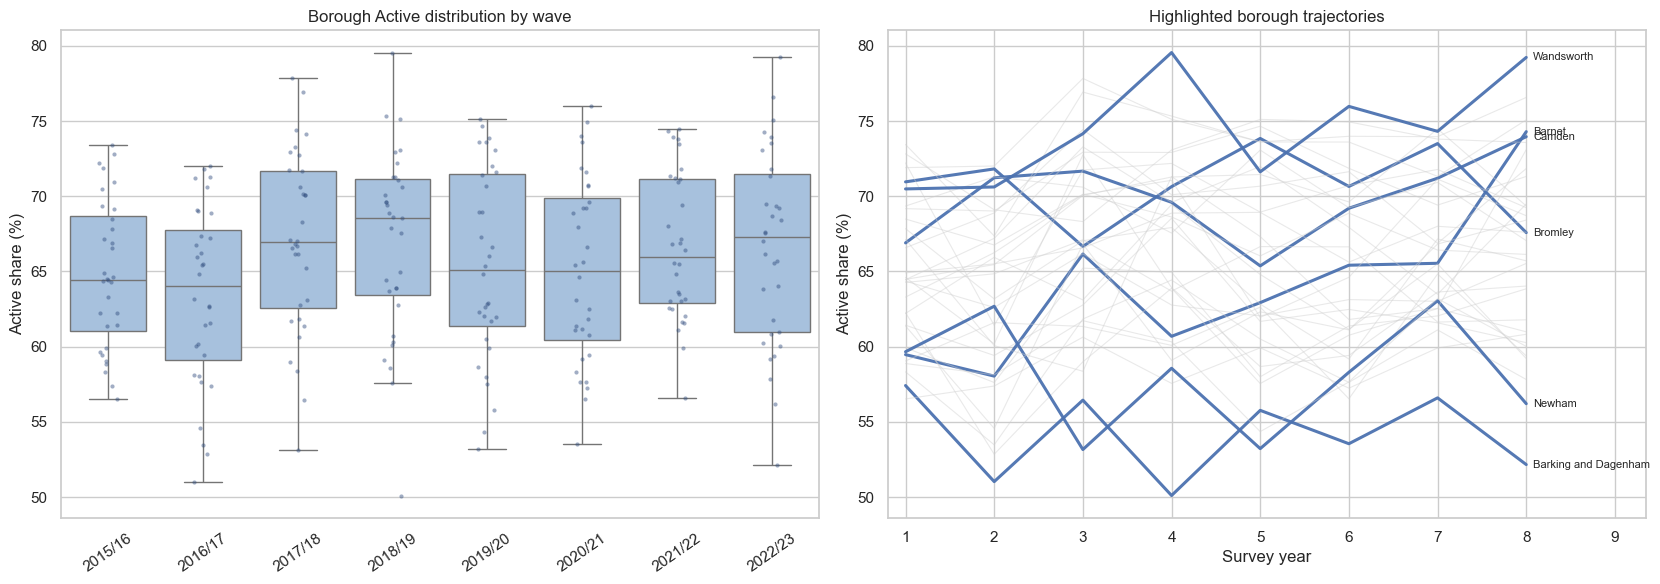

,year,q1,median,q3,sd,minimum,maximum,iqr_pp
0,1,61.01,64.46,68.66,4.89,56.53,73.44,7.65
1,2,59.09,64.01,67.74,5.94,51.03,72.01,8.65
2,3,62.54,66.93,71.69,6.02,53.16,77.83,9.15
3,4,63.46,68.58,71.11,6.21,50.11,79.55,7.65
4,5,61.39,65.09,71.49,6.39,53.22,75.11,10.10
5,6,60.43,65.01,69.88,6.16,53.55,75.97,9.45
6,7,62.90,65.98,71.15,4.87,56.60,74.47,8.26
7,8,60.95,67.32,71.45,6.49,52.16,79.23,10.50


In [9]:
# Show borough dispersion and highlight the largest endpoint trajectories.
borough_annual = add_rate_intervals(panels[('Borough', 'Annual')]).sort_values(['geography_code', 'year'])
borough_annual['active_pct'] = borough_annual['active_rate'] * 100
borough_inequality = borough_annual.groupby('year')['active_pct'].agg(
    q1=lambda x: x.quantile(.25), median='median', q3=lambda x: x.quantile(.75),
    sd='std', minimum='min', maximum='max'
).reset_index()
borough_inequality['iqr_pp'] = borough_inequality['q3'] - borough_inequality['q1']

start = borough_annual.loc[borough_annual['year'].eq(1)].set_index('geography_code')
latest = borough_annual.loc[borough_annual['year'].eq(8)].set_index('geography_code')
borough_change = pd.DataFrame({
    'geography_name': latest['geography_name'], 'start_active_pct': start['active_pct'],
    'latest_active_pct': latest['active_pct'], 'change_pp': latest['active_pct'] - start['active_pct'],
    'latest_low_pct': latest['active_rate_low'] * 100, 'latest_high_pct': latest['active_rate_high'] * 100,
}).reset_index()
highlight_codes = set(pd.concat([
    borough_change.nlargest(3, 'change_pp'), borough_change.nsmallest(3, 'change_pp')
])['geography_code'])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.boxplot(data=borough_annual, x='survey_wave', y='active_pct', color='#9EC1E6', showfliers=False, ax=axes[0])
sns.stripplot(data=borough_annual, x='survey_wave', y='active_pct', color='#2F4B7C', alpha=.45, size=3, ax=axes[0])
axes[0].set(title='Borough Active distribution by wave', xlabel='', ylabel='Active share (%)')
axes[0].tick_params(axis='x', rotation=35)

for code_value, group in borough_annual.groupby('geography_code'):
    highlighted = code_value in highlight_codes
    axes[1].plot(group['year'], group['active_pct'], color='#4C72B0' if highlighted else '#CFCFCF',
                 alpha=.95 if highlighted else .45, linewidth=2.2 if highlighted else .8)
    if highlighted:
        axes[1].text(8.08, group.iloc[-1]['active_pct'], group.iloc[-1]['geography_name'], va='center', fontsize=8)
axes[1].set_xlim(.8, 9.35)
axes[1].set(title='Highlighted borough trajectories', xlabel='Survey year', ylabel='Active share (%)')
fig.tight_layout()
plt.show()
display(borough_inequality.round(2))

The spread can be divided into persistent borough differences and movement within the same borough. A random-intercept model with year controls estimates these two variance components. The between-borough share is an intraclass correlation: the proportion of remaining variation associated with stable borough membership. The within-borough component combines genuine annual movement, measurement error and other unobserved changes, so it is not labelled as pure time variation.

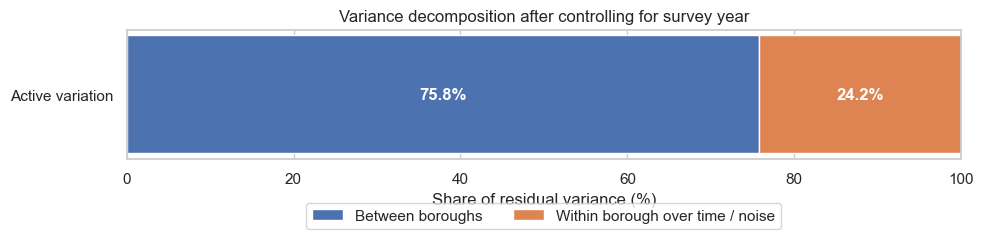

,component,variance,share_pct
0,Between boroughs,26.38,75.8
1,Within borough over time / noise,8.44,24.2


In [10]:
# Estimate how much residual variation lies between boroughs versus within boroughs over time.
borough_variance_model = smf.mixedlm(
    'active_pct ~ C(year)', borough_annual, groups=borough_annual['geography_code']
).fit(reml=True, method='lbfgs')
between_variance = float(borough_variance_model.cov_re.iloc[0, 0])
within_variance = float(borough_variance_model.scale)
borough_variance = pd.DataFrame({
    'component': ['Between boroughs', 'Within borough over time / noise'],
    'variance': [between_variance, within_variance],
})
borough_variance['share_pct'] = 100 * borough_variance['variance'] / borough_variance['variance'].sum()

fig, ax = plt.subplots(figsize=(10, 2.8))
left = 0
for (_, row), color in zip(borough_variance.iterrows(), ['#4C72B0', '#DD8452']):
    ax.barh(['Active variation'], row['share_pct'], left=left, color=color, label=row['component'])
    ax.text(left + row['share_pct'] / 2, 0, f"{row['share_pct']:.1f}%", ha='center', va='center',
            color='white', weight='bold')
    left += row['share_pct']
ax.set_xlim(0, 100)
ax.set(title='Variance decomposition after controlling for survey year', xlabel='Share of residual variance (%)', ylabel='')
ax.legend(title='', loc='upper center', bbox_to_anchor=(.5, -.28), ncol=2)
fig.tight_layout()
plt.show()
display(borough_variance.round({'variance': 2, 'share_pct': 1}))

The next view moves from the distribution to individual boroughs. The Year 8 ranking includes approximate 95% intervals so that small differences are not over-interpreted. The four-quadrant chart combines current level and eight-year direction, using the London Year 8 rate and zero change as transparent reference lines rather than arbitrary high/low cut-offs.

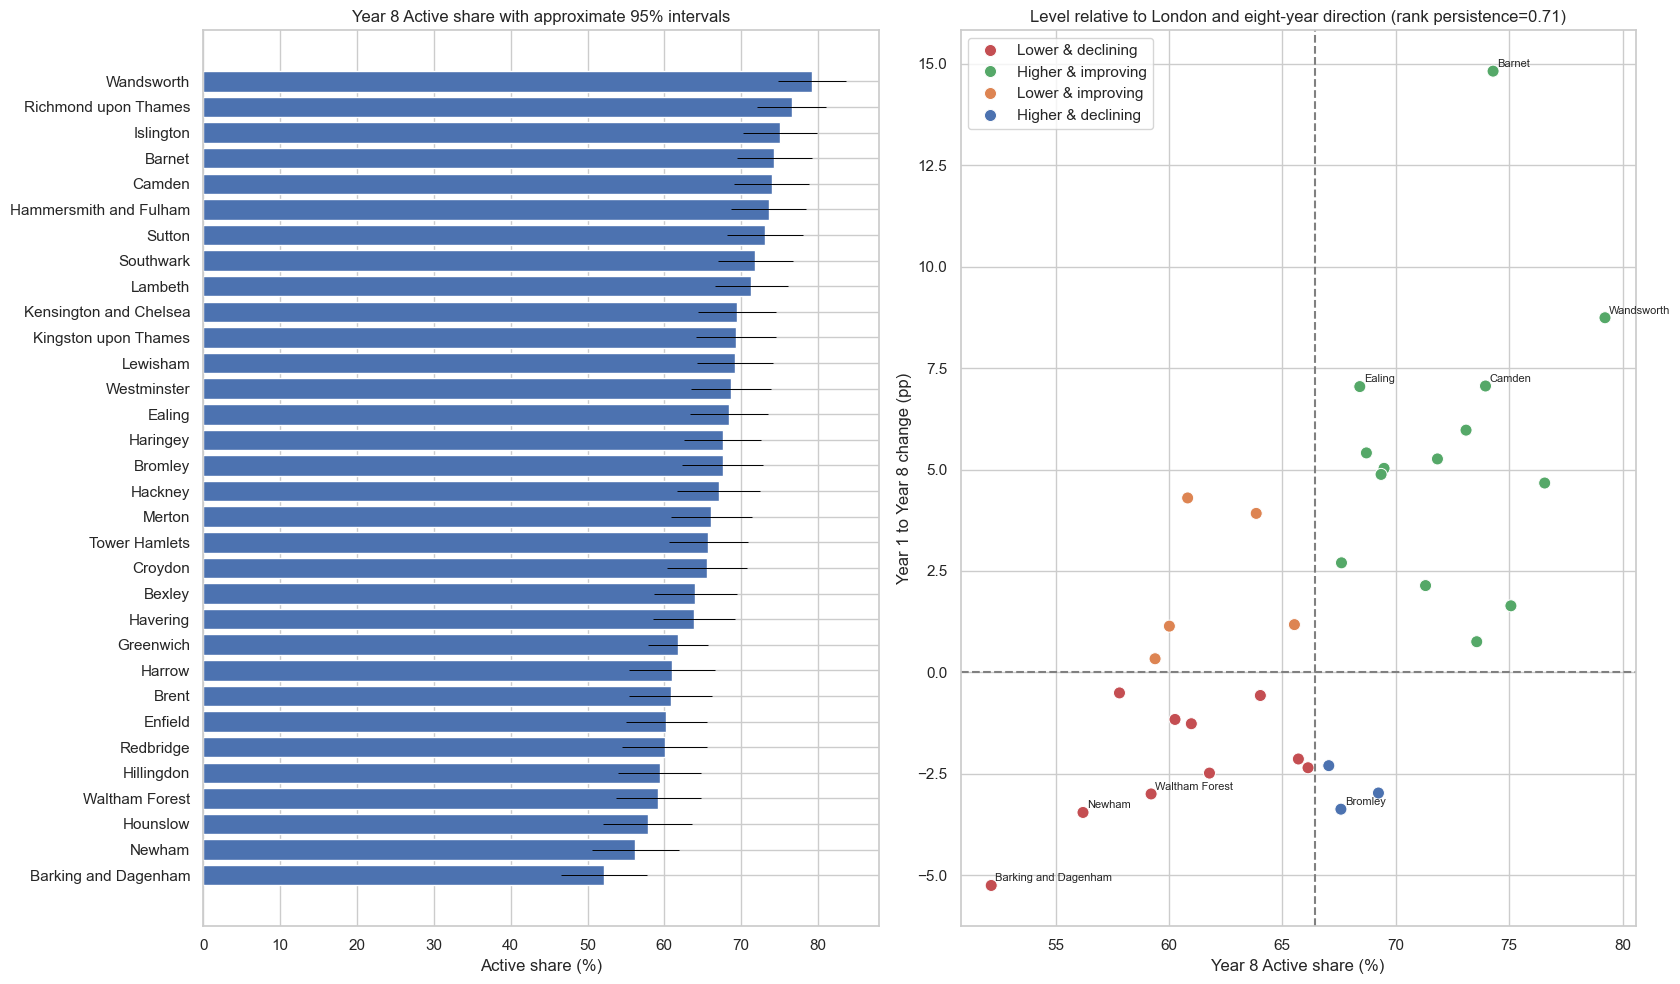

In [11]:
# Combine Year 8 rank uncertainty with level-and-change borough quadrants.
rank_correlation, rank_p = spearmanr(borough_change['start_active_pct'], borough_change['latest_active_pct'])
level_cut = london_annual.loc[london_annual['year'].eq(8), 'active_rate'].iloc[0] * 100
change_cut = 0.0
borough_change['quadrant'] = np.select(
    [
        borough_change['latest_active_pct'].ge(level_cut) & borough_change['change_pp'].ge(change_cut),
        borough_change['latest_active_pct'].ge(level_cut) & borough_change['change_pp'].lt(change_cut),
        borough_change['latest_active_pct'].lt(level_cut) & borough_change['change_pp'].ge(change_cut),
    ],
    ['Higher & improving', 'Higher & declining', 'Lower & improving'],
    default='Lower & declining',
)

fig, axes = plt.subplots(1, 2, figsize=(17, 10))
ranked = borough_change.sort_values('latest_active_pct')
axes[0].barh(ranked['geography_name'], ranked['latest_active_pct'], color='#4C72B0')
axes[0].errorbar(ranked['latest_active_pct'], ranked['geography_name'],
                 xerr=[ranked['latest_active_pct'] - ranked['latest_low_pct'],
                       ranked['latest_high_pct'] - ranked['latest_active_pct']],
                 fmt='none', color='black', linewidth=.7)
axes[0].set(title='Year 8 Active share with approximate 95% intervals', xlabel='Active share (%)', ylabel='')

quadrant_palette = {'Higher & improving': '#55A868', 'Higher & declining': '#4C72B0',
                    'Lower & improving': '#DD8452', 'Lower & declining': '#C44E52'}
sns.scatterplot(data=borough_change, x='latest_active_pct', y='change_pp', hue='quadrant',
                palette=quadrant_palette, s=75, ax=axes[1])
axes[1].axvline(level_cut, color='grey', linestyle='--')
axes[1].axhline(change_cut, color='grey', linestyle='--')
for _, row in pd.concat([borough_change.nlargest(4, 'change_pp'), borough_change.nsmallest(4, 'change_pp')]).drop_duplicates().iterrows():
    axes[1].annotate(row['geography_name'], (row['latest_active_pct'], row['change_pp']), fontsize=8, xytext=(3, 3), textcoords='offset points')
axes[1].set(title=f'Level relative to London and eight-year direction (rank persistence={rank_correlation:.2f})',
            xlabel='Year 8 Active share (%)', ylabel='Year 1 to Year 8 change (pp)')
axes[1].legend(title='')
fig.tight_layout()
plt.show()

Maps test whether borough results form geographical patterns rather than isolated rankings. The first two panels show the raw Year 8 level and eight-year change. Global Moran's I summarises overall spatial clustering; the final map identifies local high-high and low-low groups only after controlling the false discovery rate across the 32 local tests.

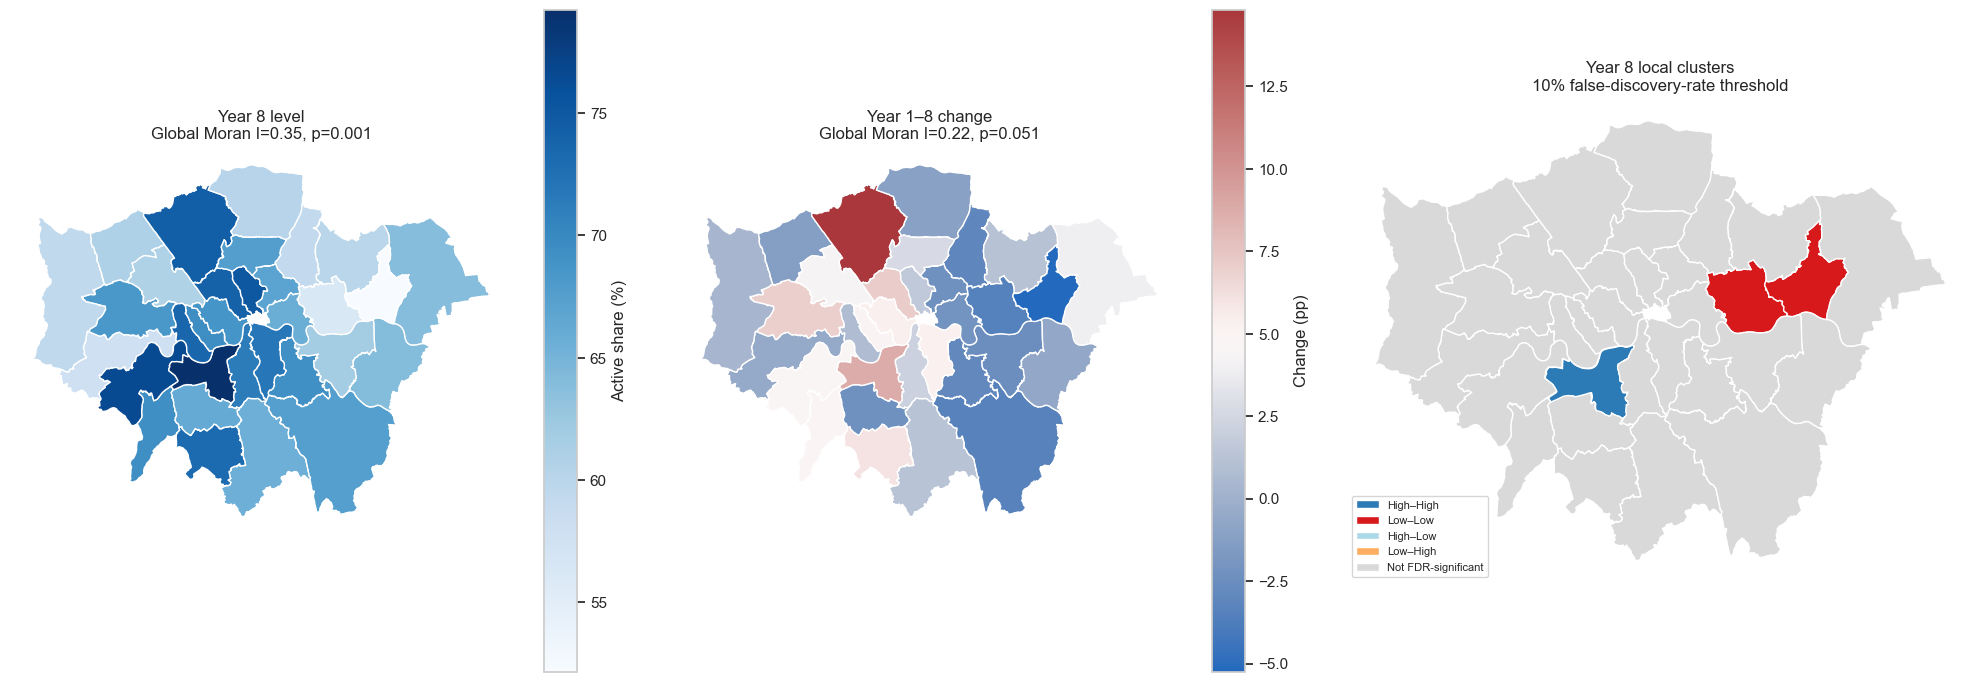

,geography_name,latest_active_pct,local_cluster,local_p,local_q
20,Wandsworth,79.227,High–High,0.005,0.053
30,Newham,56.210,Low–Low,0.005,0.053
31,Barking and Dagenham,52.163,Low–Low,0.003,0.053


In [12]:
# Map levels, changes and FDR-screened local spatial clusters.
boundaries = gpd.read_file(PATHS['Boundary'])[['gss_code', 'name', 'geometry']]
borough_map = boundaries.merge(borough_change, left_on='gss_code', right_on='geography_code', validate='one_to_one')
assert len(borough_map) == 32

def spatial_statistics(geodata, value_column, repeats=999, seed=2026):
    """Calculate global and local Moran statistics using Queen neighbours and permutations."""
    values = geodata[value_column].to_numpy(float)
    z = (values - values.mean()) / values.std(ddof=0)
    neighbours = np.array([[a.touches(b) for b in geodata.geometry] for a in geodata.geometry], dtype=float)
    np.fill_diagonal(neighbours, 0)
    row_sums = neighbours.sum(axis=1, keepdims=True)
    weights = np.divide(neighbours, row_sums, out=np.zeros_like(neighbours), where=row_sums > 0)
    global_i = len(z) / weights.sum() * (weights * z[:, None] * z[None, :]).sum() / np.square(z).sum()
    lag = weights @ z
    local_i = z * lag
    rng = np.random.default_rng(seed)
    global_null, local_null = [], np.empty((repeats, len(z)))
    for repeat in range(repeats):
        permuted = rng.permutation(z)
        global_null.append(len(z) / weights.sum() * (weights * permuted[:, None] * permuted[None, :]).sum() / np.square(permuted).sum())
        local_null[repeat] = permuted * (weights @ permuted)
    global_p = (1 + np.sum(np.abs(global_null) >= abs(global_i))) / (repeats + 1)
    local_p = (1 + np.sum(np.abs(local_null) >= np.abs(local_i), axis=0)) / (repeats + 1)
    local_q = multipletests(local_p, method='fdr_bh')[1]
    local_type = np.select(
        [(z > 0) & (lag > 0), (z < 0) & (lag < 0), (z > 0) & (lag < 0)],
        ['High–High', 'Low–Low', 'High–Low'], default='Low–High',
    )
    local_type = np.where(local_q <= .10, local_type, 'Not FDR-significant')
    return global_i, global_p, local_i, local_p, local_q, local_type

moran_level, moran_level_p, local_i, local_p, local_q, local_type = spatial_statistics(borough_map, 'latest_active_pct')
moran_change, moran_change_p, *_ = spatial_statistics(borough_map, 'change_pp', seed=2027)
borough_map['local_cluster'] = local_type
borough_map['local_p'] = local_p
borough_map['local_q'] = local_q

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
borough_map.plot(column='latest_active_pct', cmap='Blues', legend=True, edgecolor='white', ax=axes[0],
                 legend_kwds={'label': 'Active share (%)'})
axes[0].set_title(f'Year 8 level\nGlobal Moran I={moran_level:.2f}, p={moran_level_p:.3f}')
borough_map.plot(column='change_pp', cmap='vlag', legend=True, edgecolor='white', ax=axes[1],
                 legend_kwds={'label': 'Change (pp)'})
axes[1].set_title(f'Year 1–8 change\nGlobal Moran I={moran_change:.2f}, p={moran_change_p:.3f}')
local_palette = {'High–High': '#2C7BB6', 'Low–Low': '#D7191C', 'High–Low': '#ABD9E9',
                 'Low–High': '#FDAE61', 'Not FDR-significant': '#D9D9D9'}
for category, color in local_palette.items():
    local_subset = borough_map.loc[borough_map['local_cluster'].eq(category)]
    if not local_subset.empty:
        local_subset.plot(color=color, edgecolor='white', ax=axes[2])
axes[2].legend(handles=[Patch(facecolor=color, label=label) for label, color in local_palette.items()],
               loc='lower left', fontsize=8, frameon=True)
axes[2].set_title('Year 8 local clusters\n10% false-discovery-rate threshold')
for ax in axes:
    ax.set_axis_off()
fig.tight_layout()
plt.show()
display(borough_map.loc[borough_map['local_cluster'].ne('Not FDR-significant'),
                        ['geography_name', 'latest_active_pct', 'local_cluster', 'local_p', 'local_q']].round(3))

The final borough model asks a different question from the maps. Each contextual variable is separated into a borough's long-run average and its annual deviation from that average. This distinguishes persistent differences between places from changes occurring within the same place over time. Predictors are standardised so their coefficient sizes are comparable; associations remain descriptive rather than causal.

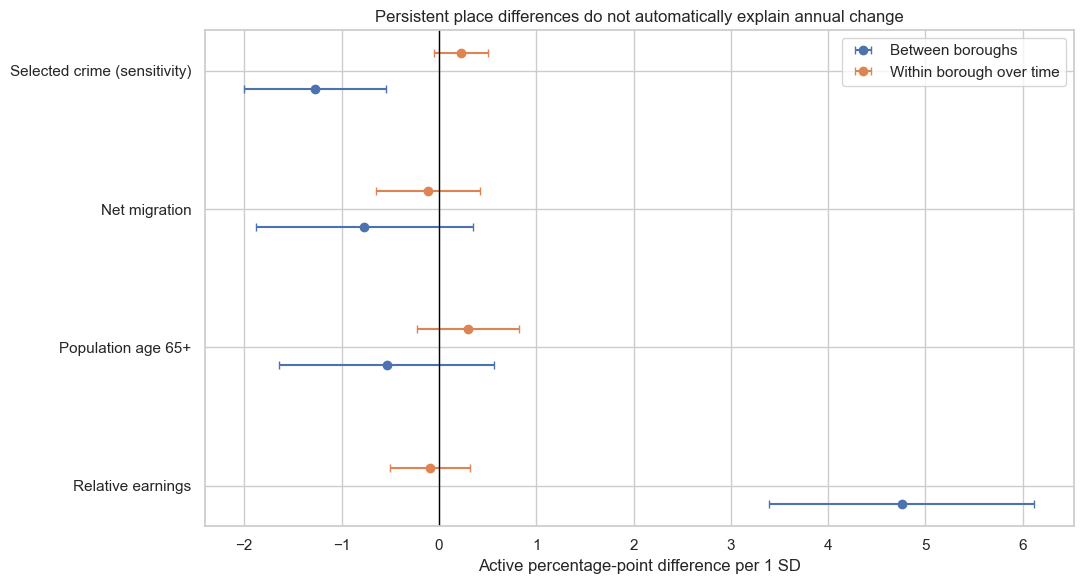

,feature,comparison,coefficient_pp,low,high,p_value
0,Relative earnings,Between boroughs,4.75,3.39,6.12,0.000
1,Relative earnings,Within borough over time,-0.09,-0.51,0.32,0.663
2,Population age 65+,Between boroughs,-0.54,-1.64,0.57,0.340
3,Population age 65+,Within borough over time,0.30,-0.23,0.82,0.269
4,Net migration,Between boroughs,-0.77,-1.88,0.35,0.179
5,Net migration,Within borough over time,-0.11,-0.65,0.42,0.683
6,Selected crime (sensitivity),Between boroughs,-1.27,-2.00,-0.54,0.001
7,Selected crime (sensitivity),Within borough over time,0.23,-0.05,0.50,0.104


In [13]:
# Fit a simultaneous within-between model with year controls and borough-clustered uncertainty.
context_features = {
    'Relative earnings': 'earnings_relative_to_london',
    'Population age 65+': 'population_age_65_plus_rate',
    'Net migration': 'net_migration_per_1000',
    'Selected crime (sensitivity)': 'selected_recorded_crime_rate_per_1000',
}
panel_model_data = borough_annual.copy()
model_terms, term_labels = [], {}
for label, column in context_features.items():
    borough_mean = panel_model_data.groupby('geography_code')[column].transform('mean')
    between_name, within_name = f'between_{column}', f'within_{column}'
    panel_model_data[between_name] = (borough_mean - borough_mean.mean()) / borough_mean.drop_duplicates().std()
    within_deviation = panel_model_data[column] - borough_mean
    panel_model_data[within_name] = within_deviation / within_deviation.std()
    model_terms.extend([between_name, within_name])
    term_labels[between_name] = (label, 'Between boroughs')
    term_labels[within_name] = (label, 'Within borough over time')

within_between_model = smf.wls(
    'active_pct ~ ' + ' + '.join(model_terms) + ' + C(year)',
    data=panel_model_data, weights=panel_model_data['effective_n'],
).fit(cov_type='cluster', cov_kwds={'groups': panel_model_data['geography_code']})
intervals = within_between_model.conf_int()
coefficient_rows = []
for term in model_terms:
    label, comparison = term_labels[term]
    coefficient_rows.append({
        'feature': label, 'comparison': comparison, 'coefficient_pp': within_between_model.params[term],
        'low': intervals.loc[term, 0], 'high': intervals.loc[term, 1], 'p_value': within_between_model.pvalues[term],
    })
within_between_effects = pd.DataFrame(coefficient_rows)

fig, ax = plt.subplots(figsize=(11, 6))
positions = np.arange(len(context_features))
for comparison, offset, color in [('Between boroughs', -.13, '#4C72B0'), ('Within borough over time', .13, '#DD8452')]:
    local = within_between_effects.loc[within_between_effects['comparison'].eq(comparison)].set_index('feature').reindex(context_features.keys())
    ax.errorbar(local['coefficient_pp'], positions + offset,
                xerr=[local['coefficient_pp'] - local['low'], local['high'] - local['coefficient_pp']],
                fmt='o', color=color, capsize=3, label=comparison)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(positions, context_features.keys())
ax.set(title='Persistent place differences do not automatically explain annual change',
       xlabel='Active percentage-point difference per 1 SD', ylabel='')
ax.legend(title='')
fig.tight_layout()
plt.show()
display(within_between_effects.round({'coefficient_pp': 2, 'low': 2, 'high': 2, 'p_value': 3}))

# 4. Respondents

The respondent records make it possible to move beyond area averages and examine what London residents actually report doing. This section starts with the eight-year activity portfolio, then considers annual trends, breadth, frequency and co-participation before returning to age. Routed or structurally missing activity items are excluded from measures that require complete, comparable indicators.

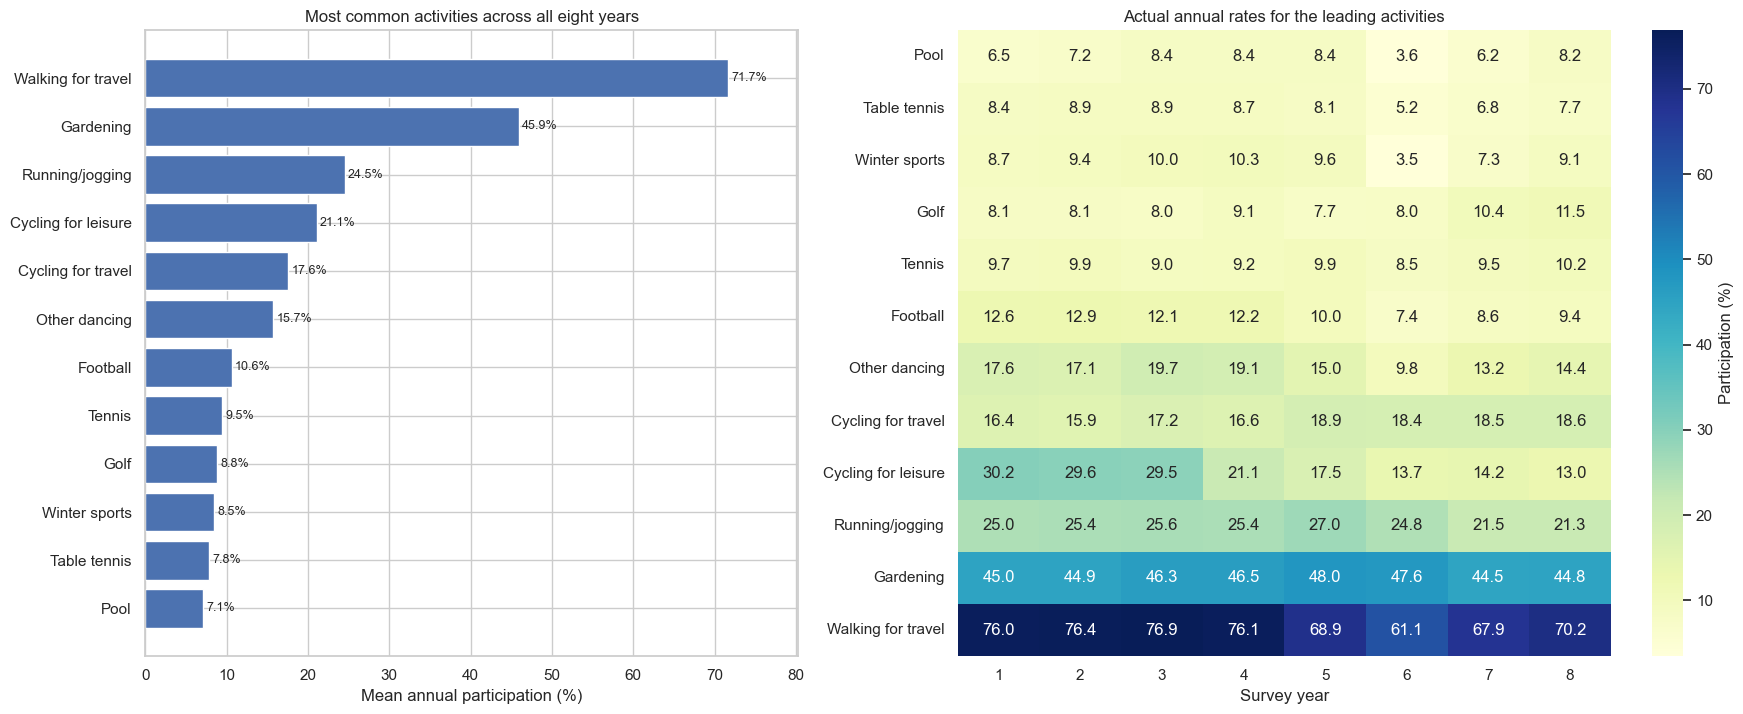

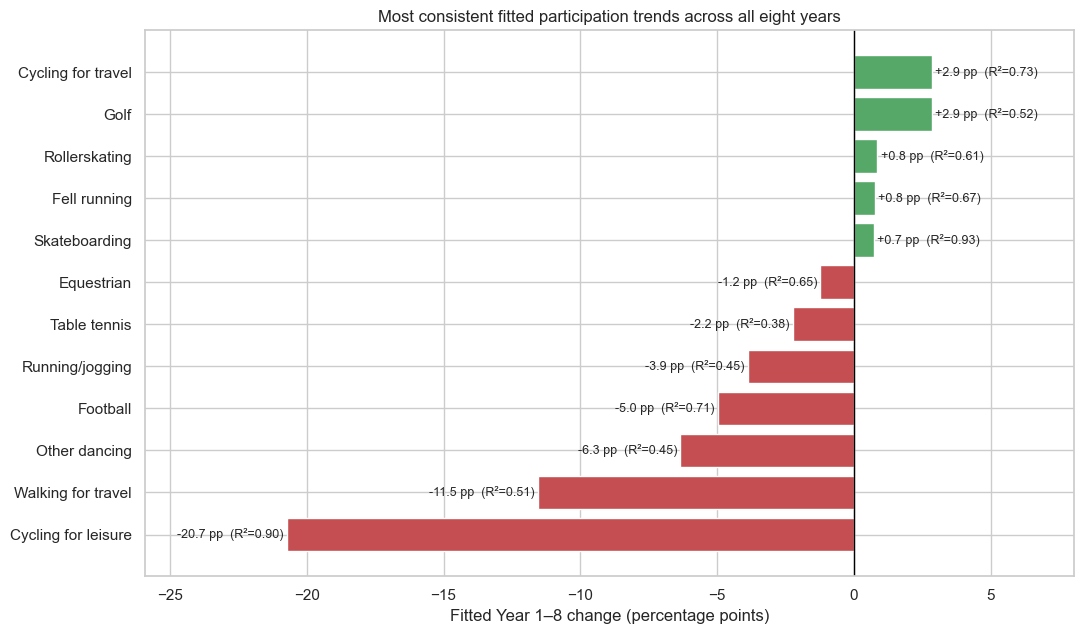

,activity,eight_year_mean_pct,fitted_change_pp,trend_r_squared,trend_p_value
0,Cycling for leisure,21.100,-20.717,0.903,0.000
1,Walking for travel,71.678,-11.539,0.508,0.047
2,Other dancing,15.745,-6.348,0.447,0.070
3,Football,10.642,-4.962,0.713,0.008
4,Running/jogging,24.512,-3.890,0.449,0.069
5,Table tennis,7.844,-2.242,0.379,0.104
6,Equestrian,1.498,-1.232,0.646,0.016
7,Skateboarding,0.814,0.737,0.929,0.000
8,Fell running,1.251,0.752,0.667,0.013
9,Rollerskating,1.107,0.849,0.606,0.023


In [14]:
# Load respondent records and calculate annual activity participation with survey weights.
months_columns = [f'MONTHS_12_{suffix}' for suffix in ACTIVITIES]
days_columns = [f'DAYS10P60GR_{suffix}' for suffix in ACTIVITIES]
breadth_suffixes = [suffix for suffix in ACTIVITIES if suffix not in {'CYCLEISURE_N01', 'ROCKCLIMB_R01'}]
breadth_columns = [f'MONTHS_12_{suffix}' for suffix in breadth_suffixes]
respondent_columns = [
    'year', 'survey_wave', 'Age9', 'Disab3', 'mode', 'MEMS7GR_ALL', 'wt_final',
    'inner_outer', 'borough', 'annual_analysis_eligible', *months_columns, *days_columns,
]
respondents = pd.read_csv(PATHS['Respondent'], usecols=respondent_columns, low_memory=False)
respondents = respondents.loc[respondents['annual_analysis_eligible']].copy()
respondents['active_binary'] = respondents['MEMS7GR_ALL'].eq(2).astype(int)
assert respondents[breadth_columns].notna().all().all()

portfolio_rows = []
for year, group in respondents.groupby('year'):
    for suffix, label in ACTIVITIES.items():
        portfolio_rows.append({
            'year': year, 'activity': label,
            'reach_pct': weighted_mean(group[f'MONTHS_12_{suffix}'], group['wt_final']) * 100,
            'frequent_pct': weighted_mean(group[f'DAYS10P60GR_{suffix}'].eq(2), group['wt_final']) * 100,
        })
portfolio = pd.DataFrame(portfolio_rows)
portfolio_wide = portfolio.pivot(index='activity', columns='year', values='reach_pct')
portfolio_summary = pd.DataFrame({'eight_year_mean_pct': portfolio_wide.mean(axis=1)})

# Estimate one linear eight-year trend per activity using all annual estimates.
trend_rows = []
for activity, group in portfolio.groupby('activity'):
    trend_model = smf.ols('reach_pct ~ year', data=group).fit()
    trend_rows.append({
        'activity': activity,
        'fitted_change_pp': trend_model.params['year'] * 7,
        'trend_r_squared': trend_model.rsquared,
        'trend_p_value': trend_model.pvalues['year'],
    })
portfolio_trends = pd.DataFrame(trend_rows).set_index('activity')
portfolio_summary = portfolio_summary.join(portfolio_trends)

top_overall = portfolio_summary.nlargest(12, 'eight_year_mean_pct').sort_values('eight_year_mean_pct')
top_matrix = portfolio_wide.reindex(top_overall.index)
stable_trends = portfolio_summary.loc[portfolio_summary['trend_r_squared'].ge(.35)]
trend_selection = pd.concat([
    stable_trends.loc[stable_trends['fitted_change_pp'].lt(0)].nsmallest(7, 'fitted_change_pp'),
    stable_trends.loc[stable_trends['fitted_change_pp'].gt(0)].nlargest(7, 'fitted_change_pp'),
]).drop_duplicates().sort_values('fitted_change_pp')

fig, axes = plt.subplots(1, 2, figsize=(18, 7.3), gridspec_kw={'width_ratios': [1, 1.25]})
axes[0].barh(top_overall.index, top_overall['eight_year_mean_pct'], color='#4C72B0')
for y, value in enumerate(top_overall['eight_year_mean_pct']):
    axes[0].text(value + .4, y, f'{value:.1f}%', va='center', fontsize=9)
axes[0].set(title='Most common activities across all eight years',
            xlabel='Mean annual participation (%)', ylabel='')
axes[0].margins(x=.12)

sns.heatmap(top_matrix, cmap='YlGnBu', annot=True, fmt='.1f',
            cbar_kws={'label': 'Participation (%)'}, ax=axes[1])
axes[1].set(title='Actual annual rates for the leading activities',
            xlabel='Survey year', ylabel='')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6.5))
trend_colors = np.where(trend_selection['fitted_change_pp'].ge(0), '#55A868', '#C44E52')
ax.barh(trend_selection.index, trend_selection['fitted_change_pp'], color=trend_colors)
ax.axvline(0, color='black', linewidth=1)
for y, (_, row) in enumerate(trend_selection.iterrows()):
    value = row['fitted_change_pp']
    ax.text(value + (.12 if value >= 0 else -.12), y,
            f"{value:+.1f} pp  (R²={row['trend_r_squared']:.2f})",
            ha='left' if value >= 0 else 'right', va='center', fontsize=9)
ax.set(title='Most consistent fitted participation trends across all eight years',
       xlabel='Fitted Year 1–8 change (percentage points)', ylabel='')
ax.margins(x=.22)
fig.tight_layout()
plt.show()
display(trend_selection.reset_index().round(3))

Participation breadth counts how many of the 38 consistently observed, non-overlapping activities each respondent reported, distinguishing non-participation from narrow and broad portfolios. The second chart separates reach—any participation in the last 12 months—from recent frequency, defined as at least two moderate sessions in the last 28 days. The two measures answer different questions and should not be treated as interchangeable.

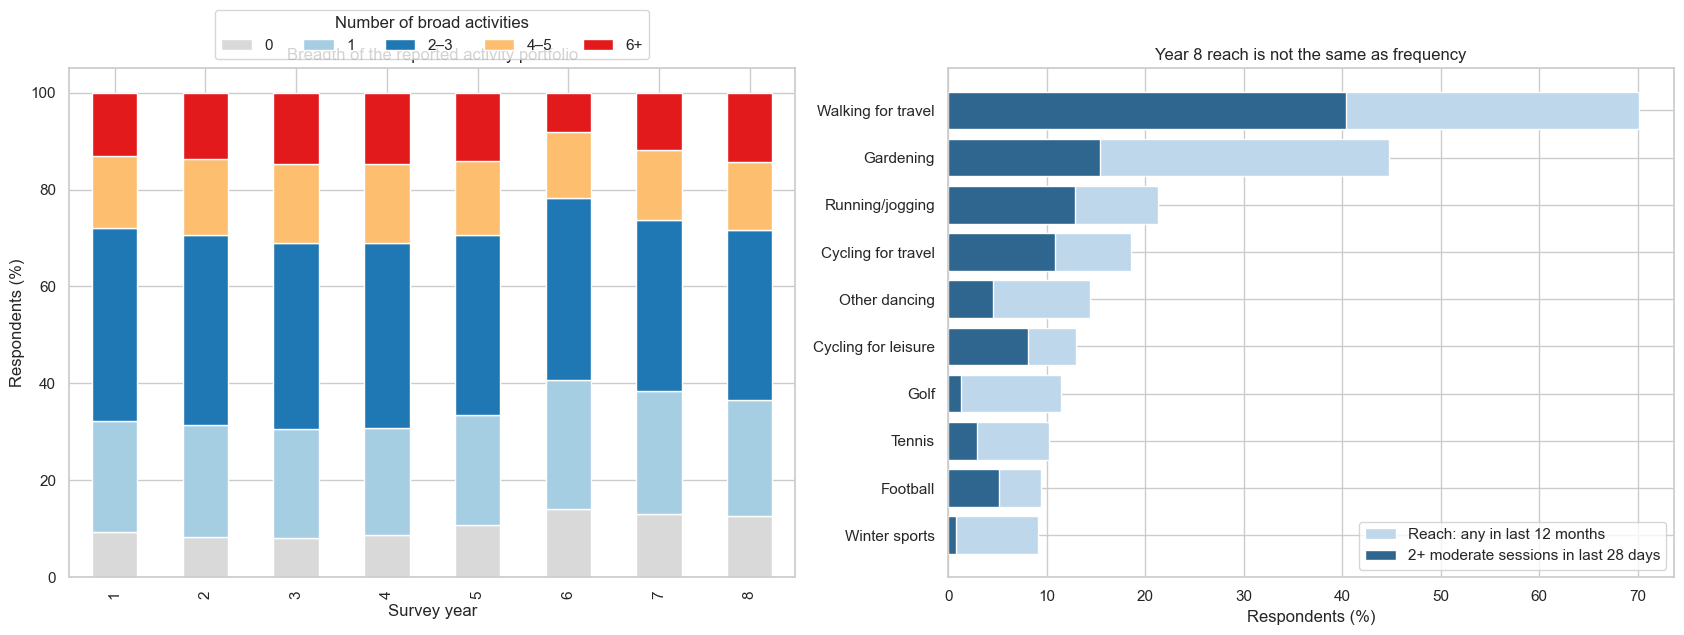

breadth,0,1,2–3,4–5,6+
year,,,,,
1,9.3,22.8,39.9,14.9,13.1
2,8.4,23.0,39.2,15.7,13.7
3,8.0,22.7,38.3,16.3,14.7
4,8.6,22.1,38.2,16.2,14.8
5,10.7,22.8,37.0,15.4,14.1
6,14.1,26.6,37.7,13.5,8.1
7,13.0,25.4,35.2,14.4,11.9
8,12.5,23.9,35.3,13.9,14.4


In [15]:
# Compare portfolio breadth and the gap between activity reach and recent frequency.
respondents['activity_breadth'] = respondents[breadth_columns].sum(axis=1)
respondents['breadth_group'] = pd.cut(
    respondents['activity_breadth'], bins=[-1, 0, 1, 3, 5, np.inf],
    labels=['0', '1', '2–3', '4–5', '6+'], right=True,
)
breadth_rows = []
for year, group in respondents.groupby('year'):
    total_weight = group['wt_final'].sum()
    for breadth, local in group.groupby('breadth_group', observed=True):
        breadth_rows.append({'year': year, 'breadth': str(breadth),
                             'share_pct': local['wt_final'].sum() / total_weight * 100})
breadth_distribution = pd.DataFrame(breadth_rows)
breadth_wide = breadth_distribution.pivot(index='year', columns='breadth', values='share_pct').fillna(0)
breadth_wide = breadth_wide.reindex(columns=['0', '1', '2–3', '4–5', '6+'])

top_frequency = portfolio.loc[portfolio['year'].eq(8)].nlargest(10, 'reach_pct').sort_values('reach_pct')
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
breadth_wide.plot(kind='bar', stacked=True, color=['#D9D9D9', '#A6CEE3', '#1F78B4', '#FDBF6F', '#E31A1C'], ax=axes[0])
axes[0].set(title='Breadth of the reported activity portfolio', xlabel='Survey year', ylabel='Respondents (%)')
axes[0].legend(title='Number of broad activities', ncol=5, loc='upper center', bbox_to_anchor=(.5, 1.13))

axes[1].barh(top_frequency['activity'], top_frequency['reach_pct'], color='#BFD7EA', label='Reach: any in last 12 months')
axes[1].barh(top_frequency['activity'], top_frequency['frequent_pct'], color='#2F6690', label='2+ moderate sessions in last 28 days')
axes[1].set(title='Year 8 reach is not the same as frequency', xlabel='Respondents (%)', ylabel='')
axes[1].legend(title='')
fig.tight_layout()
plt.show()
display(breadth_wide.round(1))

Selected activity families provide a readable summary of broader behavioural structure without displaying all activity definitions at once. They are deliberately transparent groupings rather than a new outcome scale. The co-participation heatmap then shows whether leading activities tend to be reported by the same respondents, which helps distinguish isolated activities from wider participation portfolios.

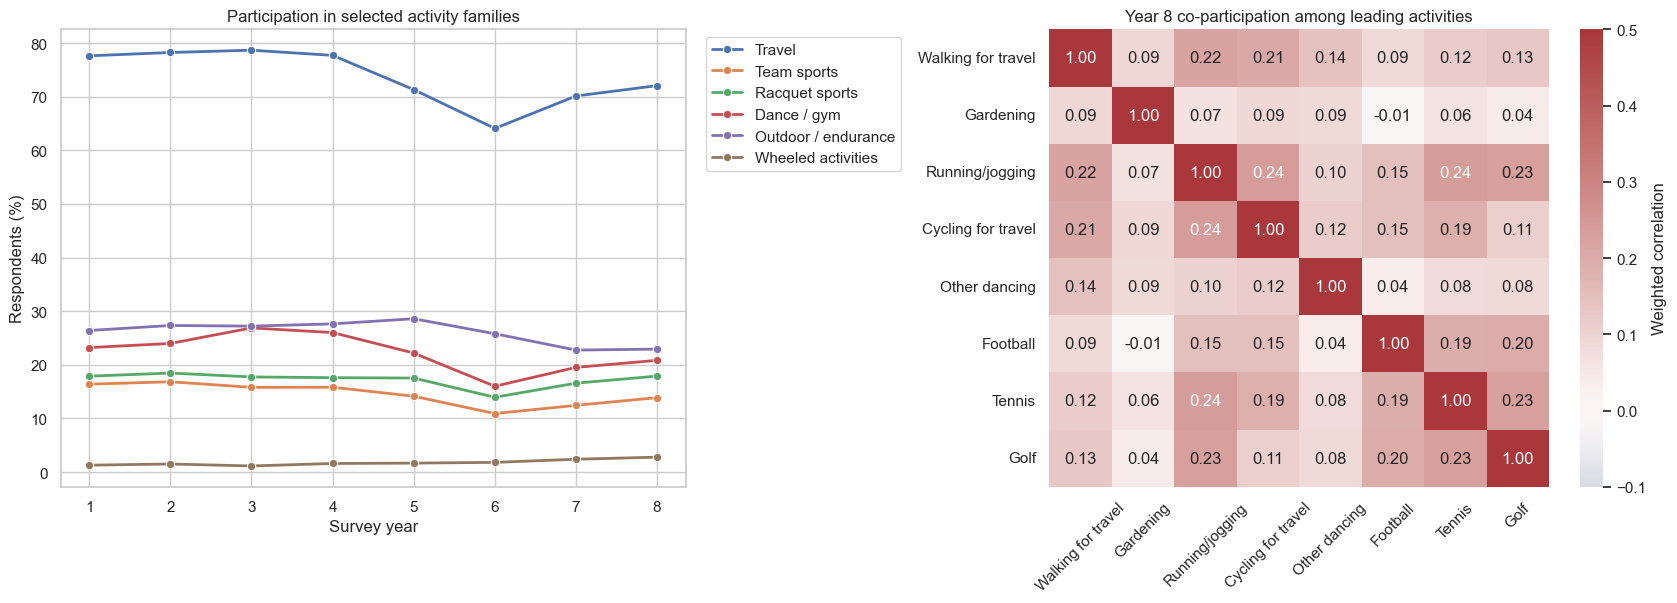

In [16]:
# Track clear activity families and calculate weighted co-participation among leading activities.
family_rows = []
for year, group in respondents.groupby('year'):
    for family, suffixes in ACTIVITY_FAMILIES.items():
        family_indicator = group[[f'MONTHS_12_{suffix}' for suffix in suffixes]].max(axis=1)
        family_rows.append({'year': year, 'family': family,
                            'participation_pct': weighted_mean(family_indicator, group['wt_final']) * 100})
family_trends = pd.DataFrame(family_rows)

complete_activity_labels = [ACTIVITIES[suffix] for suffix in breadth_suffixes]
coactivity_labels = portfolio_summary.loc[complete_activity_labels].nlargest(
    8, 'eight_year_mean_pct'
).index.tolist()
label_to_suffix = {label: suffix for suffix, label in ACTIVITIES.items()}
coactivity_columns = [f'MONTHS_12_{label_to_suffix[label]}' for label in coactivity_labels]
year8_respondents = respondents.loc[respondents['year'].eq(8)]
weights = year8_respondents['wt_final'].to_numpy(float)

def weighted_correlation(x, y, weights):
    """Calculate a weighted binary correlation for two activity indicators."""
    mean_x, mean_y = np.average(x, weights=weights), np.average(y, weights=weights)
    covariance = np.average((x - mean_x) * (y - mean_y), weights=weights)
    variance_x = np.average((x - mean_x) ** 2, weights=weights)
    variance_y = np.average((y - mean_y) ** 2, weights=weights)
    return covariance / np.sqrt(variance_x * variance_y)

coactivity_matrix = np.eye(len(coactivity_columns))
for i, first in enumerate(coactivity_columns):
    for j, second in enumerate(coactivity_columns):
        if i < j:
            value = weighted_correlation(year8_respondents[first].to_numpy(float),
                                         year8_respondents[second].to_numpy(float), weights)
            coactivity_matrix[i, j] = coactivity_matrix[j, i] = value

fig, axes = plt.subplots(1, 2, figsize=(17, 6.2))
sns.lineplot(data=family_trends, x='year', y='participation_pct', hue='family', marker='o', linewidth=2, ax=axes[0])
axes[0].set(title='Participation in selected activity families', xlabel='Survey year', ylabel='Respondents (%)')
axes[0].legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.heatmap(coactivity_matrix, vmin=-.1, vmax=.5, center=0, cmap='vlag', annot=True, fmt='.2f',
            xticklabels=coactivity_labels, yticklabels=coactivity_labels,
            cbar_kws={'label': 'Weighted correlation'}, ax=axes[1])
axes[1].set(title='Year 8 co-participation among leading activities', xlabel='', ylabel='')
axes[1].tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

Age remains important, but it is placed after the wider activity analysis so the respondent section is not reduced to demographics alone. The heatmap retains the detailed ten-year age bands across all eight waves. The adjacent three-group view summarises the same raw weighted data and makes the broad life-course pattern easier to recognise without replacing the detail.

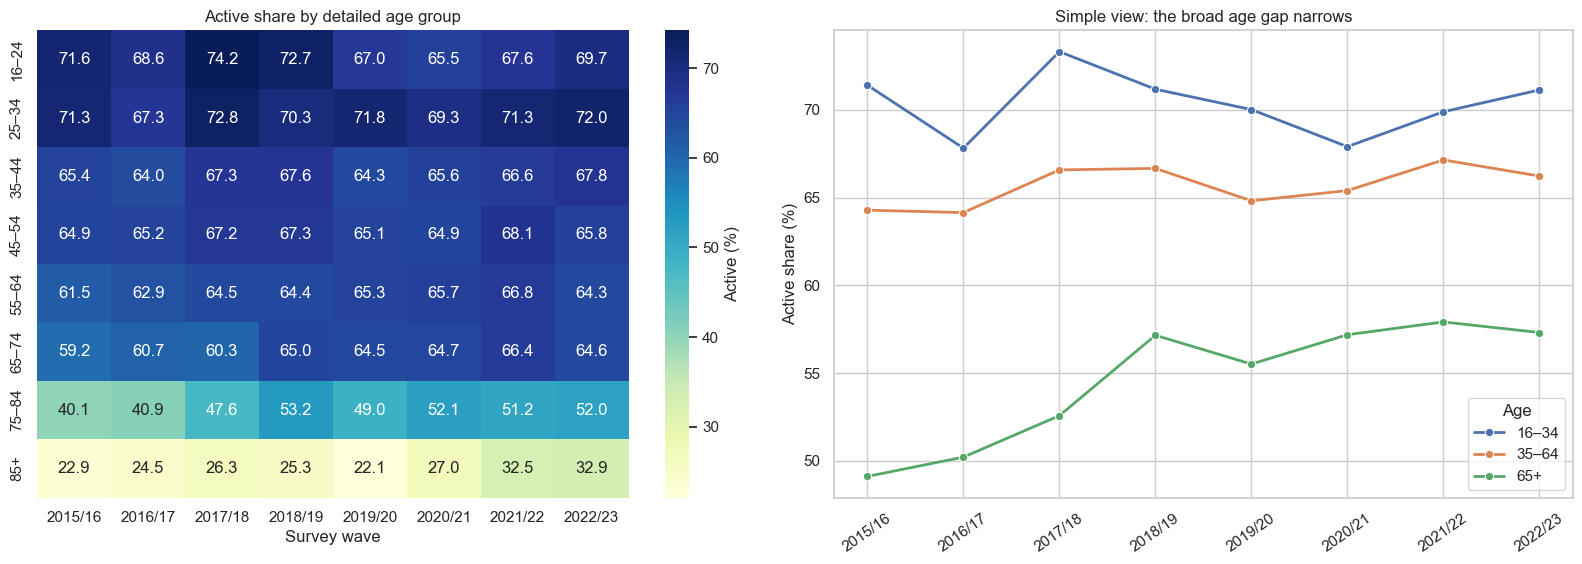

In [17]:
# Show detailed and broad age patterns using respondent weights.
age_labels = {2: '16–24', 3: '25–34', 4: '35–44', 5: '45–54', 6: '55–64', 7: '65–74', 8: '75–84', 9: '85+'}
age_macro_labels = {2: '16–34', 3: '16–34', 4: '35–64', 5: '35–64', 6: '35–64', 7: '65+', 8: '65+', 9: '65+'}
disability_labels = {1: 'Limiting disability', 2: 'Non-limiting disability', 3: 'No disability'}
mode_labels = {1: 'Online', 2: 'Paper'}
respondents['age_group'] = respondents['Age9'].map(age_labels)
respondents['age_macro'] = respondents['Age9'].map(age_macro_labels)
respondents['disability'] = respondents['Disab3'].map(disability_labels)
respondents['response_mode'] = respondents['mode'].map(mode_labels)
age_rates = weighted_group_rate(respondents.dropna(subset=['age_group']), ['survey_wave', 'age_group'])
macro_age_rates = weighted_group_rate(respondents.dropna(subset=['age_macro']), ['survey_wave', 'age_macro'])
age_order = list(age_labels.values())
wave_order = respondents[['year', 'survey_wave']].drop_duplicates().sort_values('year')['survey_wave'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
age_heat = age_rates.pivot(index='age_group', columns='survey_wave', values='active_rate').reindex(index=age_order, columns=wave_order) * 100
sns.heatmap(age_heat, cmap='YlGnBu', annot=True, fmt='.1f', cbar_kws={'label': 'Active (%)'}, ax=axes[0])
axes[0].set(title='Active share by detailed age group', xlabel='Survey wave', ylabel='')
sns.lineplot(data=macro_age_rates, x='survey_wave', y=macro_age_rates['active_rate'] * 100,
             hue='age_macro', hue_order=['16–34', '35–64', '65+'], marker='o', linewidth=2, ax=axes[1])
axes[1].set(title='Simple view: the broad age gap narrows', xlabel='', ylabel='Active share (%)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Age')
fig.tight_layout()
plt.show()

The final respondent model checks whether the age pattern remains after adjustment for survey year, Inner/Outer London, response mode and disability status. Disability is included only as a control because it is analysed elsewhere in the group project. Results are converted to adjusted probabilities rather than odds ratios so they remain on the same percentage scale as the descriptive figures.

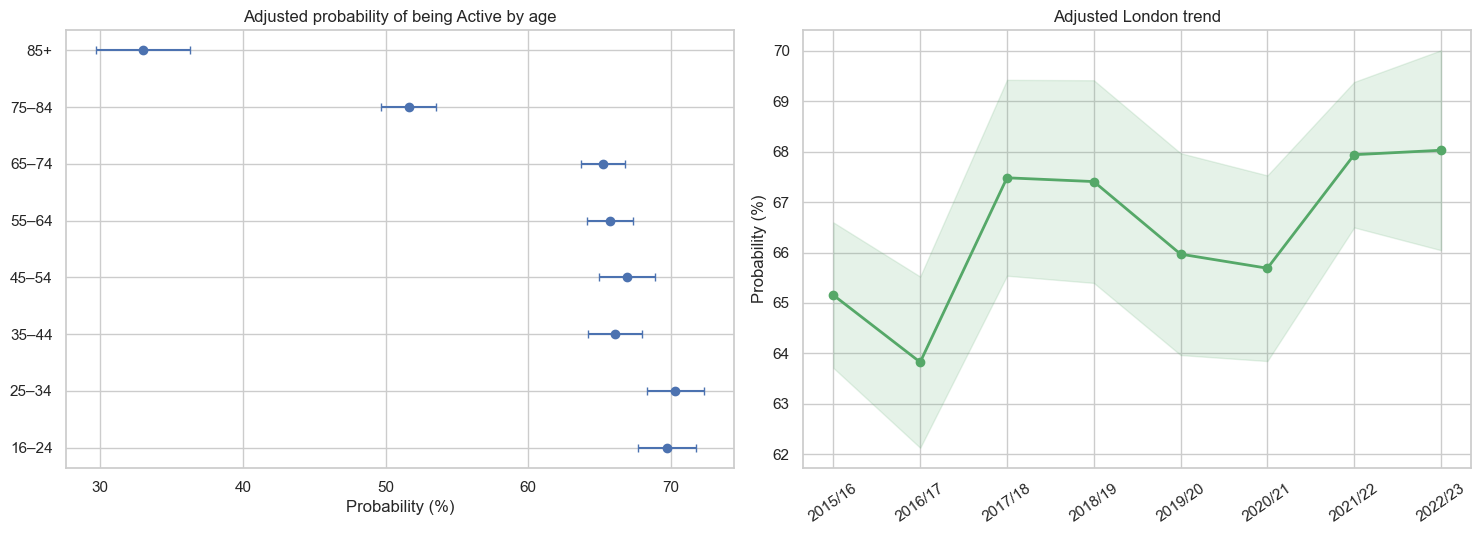

,value,probability,low,high
0,16–24,0.698,0.677,0.718
1,25–34,0.703,0.683,0.723
2,35–44,0.661,0.642,0.680
3,45–54,0.669,0.650,0.689
4,55–64,0.657,0.641,0.674
5,65–74,0.652,0.637,0.668
6,75–84,0.516,0.497,0.535
7,85+,0.330,0.297,0.363


In [18]:
# Convert the adjusted respondent model into easy-to-read probabilities.
model_data = respondents.dropna(subset=['age_group', 'disability', 'response_mode', 'inner_outer', 'borough']).copy()
model_data['age_group'] = pd.Categorical(model_data['age_group'], categories=age_order, ordered=True)
model_data['disability'] = pd.Categorical(model_data['disability'], categories=['No disability', 'Non-limiting disability', 'Limiting disability'])
model_data['response_mode'] = pd.Categorical(model_data['response_mode'], categories=['Paper', 'Online'])
model_data['inner_outer'] = pd.Categorical(model_data['inner_outer'], categories=['Outer London', 'Inner London'])
model_data['analysis_weight'] = model_data['wt_final'] / model_data['wt_final'].mean()
individual_model = smf.gee(
    'active_binary ~ C(age_group, Treatment(reference="16–24")) + '
    'C(disability, Treatment(reference="No disability")) + '
    'C(inner_outer, Treatment(reference="Outer London")) + '
    'C(response_mode, Treatment(reference="Paper")) + C(year)',
    groups='borough', data=model_data, family=sm.families.Binomial(),
    weights=model_data['analysis_weight'], cov_struct=sm.cov_struct.Independence(),
).fit()
pattern_columns = ['age_group', 'disability', 'response_mode', 'inner_outer', 'year']
standard_population = model_data.groupby(pattern_columns, observed=True, as_index=False)['analysis_weight'].sum()

def standardised_probabilities(model, population, variable, values):
    """Return marginal probabilities and delta-method intervals."""
    rows, covariance = [], model.cov_params().to_numpy()
    for value in values:
        scenario = population.copy()
        scenario[variable] = value
        if variable == 'age_group':
            scenario[variable] = pd.Categorical(scenario[variable], categories=age_order, ordered=True)
        design = np.asarray(build_design_matrices([model.model.data.design_info], scenario)[0])
        linear = design @ model.params.to_numpy()
        probability = 1 / (1 + np.exp(-linear))
        weights = scenario['analysis_weight'].to_numpy(float)
        estimate = np.average(probability, weights=weights)
        gradient = np.average(design * (probability * (1 - probability))[:, None], axis=0, weights=weights)
        standard_error = np.sqrt(gradient @ covariance @ gradient)
        rows.append({'value': value, 'probability': estimate,
                     'low': max(0, estimate - 1.96 * standard_error),
                     'high': min(1, estimate + 1.96 * standard_error)})
    return pd.DataFrame(rows)

adjusted_age_probability = standardised_probabilities(individual_model, standard_population, 'age_group', age_order)
adjusted_year_probability = standardised_probabilities(individual_model, standard_population, 'year', list(range(1, 9)))
adjusted_year_probability['survey_wave'] = adjusted_year_probability['value'].map(dict(enumerate(wave_order, start=1)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].errorbar(adjusted_age_probability['probability'] * 100, adjusted_age_probability['value'],
                 xerr=[(adjusted_age_probability['probability'] - adjusted_age_probability['low']) * 100,
                       (adjusted_age_probability['high'] - adjusted_age_probability['probability']) * 100],
                 fmt='o', color='#4C72B0', capsize=3)
axes[0].set(title='Adjusted probability of being Active by age', xlabel='Probability (%)', ylabel='')
axes[1].plot(adjusted_year_probability['survey_wave'], adjusted_year_probability['probability'] * 100,
             marker='o', color='#55A868', linewidth=2)
axes[1].fill_between(adjusted_year_probability['survey_wave'], adjusted_year_probability['low'] * 100,
                     adjusted_year_probability['high'] * 100, color='#55A868', alpha=.15)
axes[1].set(title='Adjusted London trend', xlabel='', ylabel='Probability (%)')
axes[1].tick_params(axis='x', rotation=35)
fig.tight_layout()
plt.show()
display(adjusted_age_probability.round(3))

# Main findings

## 1. London overall

- Active increased from 64.6% to 66.4% (+1.8 points). Inactive also increased from 22.2% to 23.8% (+1.6), while Fairly Active fell by 3.4 points. The annual path shows that this was not a steady improvement but a redistribution between the three statuses.
- The raw monthly series confirms repeated within-wave seasonality, but the heatmap also shows that the exact size of the pattern changes across years. The sequential STL allocation assigns 8.0% of monthly variation to the long-term path, 55.4% to recurring seasonality and 36.6% to the irregular remainder. The last component must not be read as COVID alone because it also includes survey noise and other unusual months.
- After adjustment, Active is below Pre-COVID in every later phase: 4.5 points lower during high restriction, 2.6 lower during reopening and 4.2 lower in the later period. These are adjusted period differences, not proof that COVID caused the full change.

## 2. Inner and Outer London

- Both areas are below their own Pre-COVID level in every later phase. Inner London has the larger estimated falls during high restriction (5.5 points) and the later period (5.6), compared with 3.9 and 3.0 in Outer London.
- The Inner–Outer gap does not change consistently. It narrows by 1.9 points during high restriction, but this result is borderline (p=0.050); reopening and later estimates are not statistically clear.
- Inner London's average Active advantage is 5.6 points. Equalising the age distribution reduces it to 4.5 points, so age composition explains about one fifth of the average gap. The annual decomposition shows whether this balance is stable rather than assuming one average applies to every year.
- Weighted eight-year participation rates and the complete annual gap heatmap show the persistent activity structure: Inner London is higher in travel cycling (+14.0 points), walking for travel (+10.8), running (+9.0) and leisure cycling (+7.8), while Outer London is much higher in gardening (+14.3). The specialisation index confirms that cycling for travel is the clearest Inner-oriented activity, at a little over twice the Outer rate; it remains secondary to the observed percentages.

## 3. Boroughs

- The observed borough IQR rises from 7.7 to 10.5 points, although the increase is uneven. Year 1 and Year 8 ranks remain strongly related (Spearman correlation 0.71).
- The multilevel variance model attributes 75.8% of residual variation to persistent differences between boroughs and 24.2% to within-borough annual movement plus noise. This strengthens the evidence that geography is not merely an endpoint accident, while not claiming that every borough difference is causal.
- Year 8 levels are spatially clustered (Moran's I=0.35, p=0.001), while eight-year changes are borderline (I=0.22, p=0.051). After multiple-testing adjustment, Wandsworth is High–High; Newham and Barking and Dagenham are Low–Low.
- A one-SD higher long-run earnings level is associated with 4.75 points higher Active participation between boroughs. A borough's own yearly earnings change is almost unrelated to its activity change (−0.09). Persistent place differences therefore do not automatically explain annual movement.

## 4. Respondents

- Across the full eight-year period, walking for travel, gardening, running and cycling for travel remain the most common activities. Their annual heatmap shows the underlying observations, while the fitted trend comparison uses all eight years, retains R²≥0.35 and reports R² so unstable endpoint differences are not presented as established trends.
- Leisure cycling has an exceptional fitted decline of about 20.7 points across the eight-year period and routed missing observations in some waves. It remains useful as an item-specific valid-denominator rate but is excluded from breadth, family and co-participation measures; questionnaire comparability should be checked before treating the change as behavioural evidence.
- Breadth shows a clear interruption around Year 6. Respondents reporting none of the 38 comparable activities rise from 9.3% in Year 1 to 14.1% in Year 6, then fall to 12.5% in Year 8. The 6+ group falls to 8.1% and later recovers to 14.4%.
- Reach and frequency differ sharply. In Year 8, walking reaches 70.2% but 40.4% report at least two recent moderate sessions; gardening reaches 44.8% but frequent participation is 15.4%. Golf and winter sports have relatively broad reach but little frequent participation.
- Travel, team sport, dance/gym and outdoor/endurance participation are all lower in Year 8 than Year 1. Racquet participation is almost unchanged, while the smaller wheeled-activity family rises.
- Co-participation relationships are modest. The strongest among the leading activities is running with cycling for travel (correlation 0.24), so there is no single dominant activity bundle.
- The adjusted age pattern remains fairly level from ages 16–74 (about 65–70%), then falls to 51.6% at 75–84 and 33.0% at 85+.